# the Second Attempt

In [ ]:
!pip install selenium webdriver_manager
!apt-get update
!apt-get install -y wget unzip
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://ar

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import time
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup, NavigableString, Tag
import requests
import re
from urllib.parse import quote, unquote, urlunparse, urlparse
import openpyxl
import uuid
import ast
from urllib.parse import urlparse, parse_qs
import urllib.request, json
import seaborn as sns
import matplotlib.pyplot as plt


chrome_options = Options()
chrome_options.add_argument("--disable-extensions")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-dev-shm-usage")
chrome_options.add_argument("--headless")
chrome_options.add_argument("--incognito")
chrome_options.add_argument("--disable-site-isolation-trials")


def result_match(result_text):
    if result_text == '1 - 0':
        return 1
    elif result_text == '½ - ½':
        return 0.5
    else:
        return 0

def result_match_black(result_text):
    if result_text == '1 - 0':
        return 0
    elif result_text == '½ - ½':
        return 0.5
    else:
        return 1



In [ ]:
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)

In [ ]:
tournament_url = 'https://www.chess.com/tournament/live/late-titled-tuesday-blitz-may-07-2024-4753864?round=1&pairings=1'

driver.get(tournament_url)

In [ ]:

soup = BeautifulSoup(driver.page_source, 'html.parser')


In [ ]:
# White name
white_name = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[0].get('title')
# White link
white_link = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[0].get('href')
# White rating
white_rating = int(soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('span', class_='user-rating')[0].text.strip('()'))
# White Title
white_title = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-title')[0].text.strip()



In [ ]:
# Black name
black_name = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[1].get('title')
# Black link
black_link = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[1].get('href')
# Black rating
black_rating = int(soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('span', class_='user-rating')[1].text.strip('()'))
# Black Title
black_title = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('a', class_='post-view-meta-title')[1].text.strip()

# White win
result_text = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[1].find_all('td')[1].text.strip()
result_white = result_match(result_text)

# Date
date = ' '.join(soup.find('div', class_='tournaments-live-view-content-stats').find_all('span')[2].text.strip().split('\u202f'))

# Round
parsed_url = urlparse(tournament_url)
query_params = parse_qs(parsed_url.query)
round_number = query_params.get('round', [None])[0]


In [ ]:
from tqdm import tqdm

df_full = pd.DataFrame()

tournament_url = f'https://www.chess.com/tournament/live/late-titled-tuesday-blitz-july-16-2024-4900935?round={1}&pairings={1}'
driver.get(tournament_url)
soup = BeautifulSoup(driver.page_source, 'html.parser')

for j in tqdm(range(len(soup.find('div', class_='form-dropdown-options').find_all('div')))):
  k = 1
  while k > 0:
    tournament_url = f'https://www.chess.com/tournament/live/late-titled-tuesday-blitz-july-16-2024-4900935?round={j}&pairings={k}'

    driver.get(tournament_url)
    soup = BeautifulSoup(driver.page_source, 'html.parser')

    if len(soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')) > 1:
      games = soup.find(class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')

      for i in range(1, len(games)):
        # White name
        white_name = games[i].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[0].get('title')
        # White link
        white_link = games[i].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[0].get('href')
        # White rating
        white_rating = int(games[i].find_all('span', class_='user-rating')[0].text.strip('()'))
        # White Title
        white_title = games[i].find_all('a', class_='post-view-meta-title')[0].text.strip()

        # Black name
        black_name = games[i].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[1].get('title')
        # Black link
        black_link = games[i].find_all('a', class_='post-view-meta-avatar tournaments-live-view-player-avatar')[1].get('href')
        # Black rating
        black_rating = int(games[i].find_all('span', class_='user-rating')[1].text.strip('()'))
        # Black Title
        black_title = games[i].find_all('a', class_='post-view-meta-title')[1].text.strip()

        # White win
        result_text = games[i].find_all('td')[1].text.strip()
        result_white = result_match(result_text)

        # Black win
        result_black = result_match_black(result_text)

        # Date
        date = ' '.join(soup.find('div', class_='tournaments-live-view-content-stats').find_all('span')[2].text.strip().split('\u202f'))

        # Round
        parsed_url = urlparse(tournament_url)
        query_params = parse_qs(parsed_url.query)
        round_number = int(query_params.get('round', [None])[0]) + 1

        # Game link
        game_link = soup.find('table', class_='table-component table-hover tournaments-live-view-pairings-table').find_all('tr')[i].find('a', class_='tournaments-live-view-background-link').get('href')

        # Parse accuracies
        white_name_link = white_name.lower()
        year = pd.to_datetime(date).year
        month = pd.to_datetime(date).month
        month = [f'0{month}' if month < 10 else f'{month}'][0]
        games_link = f"https://api.chess.com/pub/player/{white_name_link}/games/{year}/{month}"

        with urllib.request.urlopen(games_link) as url:
          data = json.load(url)

        for i, game in enumerate(data['games']):
          if game['url'] == game_link:
            if 'accuracies' in game:
              accuracy_white = game['accuracies']['white']
              accuracy_black = game['accuracies']['black']

            else:
              accuracy_white = ''
              accuracy_black = ''


        data = [{
            'white_name': white_name,
            'white_link': white_link,
            'white_rating': white_rating,
            'white_title': white_title,
            'black_name': black_name,
            'black_link': black_link,
            'black_rating': black_rating,
            'black_title': black_title,
            'result_white': result_white,
            'result_black': result_black,
            'date': date,
            'round': round_number,
            'game_link': game_link,
            'accuracy_white': accuracy_white,
            'accuracy_black': accuracy_black
        }]

        df = pd.DataFrame(data)
        df_full = pd.concat([df_full, df], ignore_index=True, axis=0)
      k += 1
    else:
      k = -1



100%|██████████| 11/11 [18:18<00:00, 99.89s/it]


## Parsing several tournaments

In [ ]:
from tqdm import tqdm
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)

links_tournaments = []
for i in tqdm(range(1, 7)):
  tournaments_page = f'https://www.chess.com/tournament/live/titled-tuesdays?&page={i}'
  driver.get(tournaments_page)
  soup = BeautifulSoup(driver.page_source, 'html.parser')

  for x in [x.get('href') for x in soup.find_all('a', class_='tournaments-live-name')]:
    links_tournaments.append(x)

100%|██████████| 6/6 [00:25<00:00,  4.20s/it]


In [ ]:
links_tournaments = pd.DataFrame(links_tournaments, columns=['tournaments']).reset_index().rename(columns={'index': 'tournament_number'})
links_tournaments.to_csv('links_tournaments.csv')
links_tournaments.head(5)

,tournament_number,tournaments
0,0,https://www.chess.com/tournament/live/titled-t...
1,1,https://www.chess.com/tournament/live/titled-t...
2,2,https://www.chess.com/tournament/live/titled-t...
3,3,https://www.chess.com/tournament/live/titled-t...
4,4,https://www.chess.com/tournament/live/titled-t...


In [ ]:
links_tournaments = pd.read_csv('links_tournaments_2026.csv')
links_tournaments.head(5)

,Unnamed: 0,tournament_number,tournaments
0,0,0,https://www.chess.com/tournament/live/titled-t...
1,1,1,https://www.chess.com/tournament/live/titled-t...
2,2,2,https://www.chess.com/tournament/live/titled-t...
3,3,3,https://www.chess.com/tournament/live/titled-t...
4,4,4,https://www.chess.com/tournament/live/titled-t...


In [ ]:
links_tournaments

,Unnamed: 0,tournament_number,tournaments
0,0,0,https://www.chess.com/tournament/live/titled-t...
1,1,1,https://www.chess.com/tournament/live/titled-t...
2,2,2,https://www.chess.com/tournament/live/titled-t...
3,3,3,https://www.chess.com/tournament/live/titled-t...
4,4,4,https://www.chess.com/tournament/live/titled-t...
...,...,...,...
145,145,145,https://www.chess.com/tournament/live/late-tit...
146,146,146,https://www.chess.com/tournament/live/early-ti...
147,147,147,https://www.chess.com/tournament/live/late-tit...
148,148,148,https://www.chess.com/tournament/live/early-ti...


## A new more sustainable version

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import time
import urllib.request
import pandas as pd

from tqdm import tqdm
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs

from selenium import webdriver
from selenium.common.exceptions import TimeoutException, WebDriverException


# =========================
# CONFIG
# =========================
SAVE_CSV = "last_saved_version.csv"
CHECKPOINT_FILE = "checkpoint.json"
MAX_RETRIES = 3
SLEEP_BETWEEN_RETRIES = 5


# =========================
# HELPERS
# =========================
def create_driver(chrome_options):
    driver = webdriver.Chrome(options=chrome_options)
    driver.set_page_load_timeout(600)
    return driver


def safe_quit(driver):
    try:
        if driver is not None:
            driver.quit()
    except Exception:
        pass


def save_checkpoint(l, j, k):
    checkpoint = {"l": l, "j": j, "k": k}
    with open(CHECKPOINT_FILE, "w", encoding="utf-8") as f:
        json.dump(checkpoint, f)


def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, "r", encoding="utf-8") as f:
            return json.load(f)
    return {"l": 5, "j": 1, "k": 1}


def fetch_soup(driver, url):
    driver.get(url)
    return BeautifulSoup(driver.page_source, "html.parser")


def get_pairings_table(soup):
    return soup.find("table", class_="table-component table-hover tournaments-live-view-pairings-table")


def get_round_count(soup):
    dropdown = soup.find("div", class_="form-dropdown-options")
    if dropdown is None:
        return 0
    return len(dropdown.find_all("div"))


def parse_rating(span_list, idx):
    try:
        txt = span_list[idx].text.strip().strip("()")
        if txt == "Unrated":
            return 0
        return int(txt)
    except Exception:
        return 0


def parse_title(player_info_block):
    try:
        title_tag = player_info_block.find("a", class_="cc-user-title-component cc-text-x-small-bold")
        return title_tag.text.strip() if title_tag else "No Title"
    except Exception:
        return "No Title"


def parse_player_info(game_row, side_idx):
    player_infos = game_row.find_all("div", class_="tournaments-live-view-player-info")
    if len(player_infos) <= side_idx:
        return None

    block = player_infos[side_idx]

    name_tag = block.find("a", class_="cc-text-medium-bold cc-user-username-component cc-user-username-default")
    name = name_tag.text.strip() if name_tag else ""

    link = name_tag.get("href") if name_tag else ""

    return {
        "name": name,
        "link": link,
        "title": parse_title(block)
    }


def get_date_from_soup(soup):
    stats_div = soup.find("div", class_="tournaments-live-view-content-stats")
    if stats_div is None:
        return None
    spans = stats_div.find_all("span")
    if len(spans) < 3:
        return None
    return " ".join(spans[2].text.strip().split("\u202f"))


def get_accuracies(white_name, date, game_link):
    accuracy_white = ""
    accuracy_black = ""

    try:
        white_name_link = white_name.lower()
        dt = pd.to_datetime(date)
        year = dt.year
        month = f"{dt.month:02d}"

        games_link = f"https://api.chess.com/pub/player/{white_name_link}/games/{year}/{month}"

        with urllib.request.urlopen(games_link) as url:
            api_data = json.load(url)

        for game in api_data.get("games", []):
            if game.get("url") == game_link:
                acc = game.get("accuracies", {})
                accuracy_white = acc.get("white", "")
                accuracy_black = acc.get("black", "")
                break

    except Exception as e:
        print(f"[API WARNING] Could not fetch accuracies for {white_name}, {date}, {game_link}. Error: {e}")

    return accuracy_white, accuracy_black


def load_existing_data():
    if os.path.exists(SAVE_CSV):
        try:
            return pd.read_csv(SAVE_CSV)
        except Exception:
            pass
    return pd.DataFrame()


# =========================
# MAIN SCRAPER
# =========================
df_full = load_existing_data()
checkpoint = load_checkpoint()

start_l = 94
start_j = 1
start_k = 1

driver = None

try:
    driver = create_driver(chrome_options)

    for l in range(start_l, 150):
        link_tournament_l = links_tournaments["tournaments"][l]
        first_url = f"{link_tournament_l}?round=1&pairings=1"

        # If first page itself fails, retry with driver restart
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                soup = fetch_soup(driver, first_url)
                n_rounds = get_round_count(soup)

                if n_rounds == 0:
                    print(f"[WARNING] No rounds found for tournament index l={l}. Skipping tournament.")
                    n_rounds = 0
                break
            except Exception as e:
                print(f"[ERROR] Failed to load initial tournament page for l={l}, attempt={attempt}/{MAX_RETRIES}. Error: {e}")
                safe_quit(driver)
                time.sleep(SLEEP_BETWEEN_RETRIES)
                driver = create_driver(chrome_options)
        else:
            print(f"[FATAL] Could not initialize tournament l={l}. Skipping.")
            continue

        current_start_j = start_j if l == start_l else 1

        for j in tqdm(range(current_start_j, n_rounds + 1), desc=f"Tournament {l}"):
            k = start_k if (l == start_l and j == current_start_j) else 1

            while k > 0:
                tournament_url = f"{link_tournament_l}?round={j}&pairings={k}"
                save_checkpoint(l, j, k)

                success = False
                for attempt in range(1, MAX_RETRIES + 1):
                    try:
                        soup = fetch_soup(driver, tournament_url)
                        table = get_pairings_table(soup)

                        if table is None:
                            raise ValueError("Pairings table not found in HTML")

                        rows = table.find_all("tr")
                        success = True
                        break

                    except Exception as e:
                        print(
                            f"[ERROR] Failed at l={l}, j={j}, k={k}, "
                            f"attempt={attempt}/{MAX_RETRIES}. Restarting driver. Error: {e}"
                        )
                        safe_quit(driver)
                        time.sleep(SLEEP_BETWEEN_RETRIES)
                        driver = create_driver(chrome_options)

                if not success:
                    print(f"[FATAL] Could not recover page l={l}, j={j}, k={k}. Progress saved. Stopping.")
                    raise RuntimeError(f"Unrecoverable failure at l={l}, j={j}, k={k}")

                # no pairings on this page => end of pairings for this round
                if len(rows) <= 1:
                    print(f"[INFO] No more pairings for l={l}, j={j}, k={k}. Moving to next round.")
                    k = -1
                    continue

                date = get_date_from_soup(soup)
                if date is None:
                    print(f"[WARNING] Date not found for l={l}, j={j}, k={k}. Using empty string.")
                    date = ""

                for row_idx in range(1, len(rows)):
                    try:
                        game_row = rows[row_idx]

                        white = parse_player_info(game_row, 0)
                        black = parse_player_info(game_row, 1)

                        if white is None or black is None:
                            print(f"[WARNING] Missing player info at l={l}, j={j}, k={k}, row={row_idx}. Skipping row.")
                            continue

                        rating_spans = game_row.find_all("span", class_="user-rating")
                        white_rating = parse_rating(rating_spans, 0)
                        black_rating = parse_rating(rating_spans, 1)

                        tds = game_row.find_all("td")
                        if len(tds) < 2:
                            print(f"[WARNING] Missing result cell at l={l}, j={j}, k={k}, row={row_idx}. Skipping row.")
                            continue

                        result_text = tds[1].text.strip()
                        result_white = result_match(result_text)
                        result_black = result_match_black(result_text)

                        link_tag = game_row.find("a", class_="tournaments-live-view-background-link")
                        game_link = link_tag.get("href") if link_tag else ""

                        accuracy_white, accuracy_black = get_accuracies(
                            white_name=white["name"],
                            date=date,
                            game_link=game_link
                        )

                        row_data = [{
                            "white_name": white["name"],
                            "white_link": white["link"],
                            "white_rating": white_rating,
                            "white_title": white["title"],
                            "black_name": black["name"],
                            "black_link": black["link"],
                            "black_rating": black_rating,
                            "black_title": black["title"],
                            "result_white": result_white,
                            "result_black": result_black,
                            "date": date,
                            "round": j,
                            "pairings": k,
                            "game_link": game_link,
                            "accuracy_white": accuracy_white,
                            "accuracy_black": accuracy_black
                        }]

                        df = pd.DataFrame(row_data)
                        df_full = pd.concat([df_full, df], ignore_index=True)

                    except Exception as e:
                        print(f"[ROW WARNING] Failed at l={l}, j={j}, k={k}, row={row_idx}. Error: {e}")
                        continue

                # save after each pairings page
                df_full.to_csv(SAVE_CSV, index=False)
                df_full.to_csv(f'/content/drive/MyDrive/chess_data/{SAVE_CSV}', index=False)

                print(f"[SAVED] Progress saved after l={l}, j={j}, k={k}")

                k += 1

        # after finishing one tournament, reset j/k start points
        start_j = 1
        start_k = 1

    print("[DONE] Scraping finished successfully.")

    # remove checkpoint if fully done
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)

finally:
    safe_quit(driver)

Tournament 94:   0%|          | 0/11 [00:00<?, ?it/s]

[SAVED] Progress saved after l=94, j=1, k=1
[SAVED] Progress saved after l=94, j=1, k=2
[SAVED] Progress saved after l=94, j=1, k=3
[SAVED] Progress saved after l=94, j=1, k=4
[SAVED] Progress saved after l=94, j=1, k=5
[SAVED] Progress saved after l=94, j=1, k=6
[SAVED] Progress saved after l=94, j=1, k=7
[SAVED] Progress saved after l=94, j=1, k=8
[SAVED] Progress saved after l=94, j=1, k=9
[SAVED] Progress saved after l=94, j=1, k=10
[SAVED] Progress saved after l=94, j=1, k=11
[SAVED] Progress saved after l=94, j=1, k=12
[SAVED] Progress saved after l=94, j=1, k=13
[SAVED] Progress saved after l=94, j=1, k=14
[SAVED] Progress saved after l=94, j=1, k=15
[SAVED] Progress saved after l=94, j=1, k=16
[SAVED] Progress saved after l=94, j=1, k=17
[SAVED] Progress saved after l=94, j=1, k=18


Tournament 94:   9%|▉         | 1/11 [06:55<1:09:18, 415.88s/it]

[INFO] No more pairings for l=94, j=1, k=19. Moving to next round.
[SAVED] Progress saved after l=94, j=2, k=1
[SAVED] Progress saved after l=94, j=2, k=2
[SAVED] Progress saved after l=94, j=2, k=3
[SAVED] Progress saved after l=94, j=2, k=4
[SAVED] Progress saved after l=94, j=2, k=5
[SAVED] Progress saved after l=94, j=2, k=6
[SAVED] Progress saved after l=94, j=2, k=7
[SAVED] Progress saved after l=94, j=2, k=8
[SAVED] Progress saved after l=94, j=2, k=9
[SAVED] Progress saved after l=94, j=2, k=10
[SAVED] Progress saved after l=94, j=2, k=11
[SAVED] Progress saved after l=94, j=2, k=12
[SAVED] Progress saved after l=94, j=2, k=13
[SAVED] Progress saved after l=94, j=2, k=14
[SAVED] Progress saved after l=94, j=2, k=15
[SAVED] Progress saved after l=94, j=2, k=16
[SAVED] Progress saved after l=94, j=2, k=17
[SAVED] Progress saved after l=94, j=2, k=18


Tournament 94:  18%|█▊        | 2/11 [13:19<59:34, 397.13s/it]  

...

[INFO] No more pairings for l=112, j=8, k=11. Moving to next round.
[SAVED] Progress saved after l=112, j=9, k=1
[SAVED] Progress saved after l=112, j=9, k=2
[SAVED] Progress saved after l=112, j=9, k=3
[SAVED] Progress saved after l=112, j=9, k=4
[SAVED] Progress saved after l=112, j=9, k=5
[SAVED] Progress saved after l=112, j=9, k=6
[SAVED] Progress saved after l=112, j=9, k=7
[SAVED] Progress saved after l=112, j=9, k=8
[SAVED] Progress saved after l=112, j=9, k=9


Tournament 112:  82%|████████▏ | 9/11 [33:13<06:10, 185.42s/it]

[INFO] No more pairings for l=112, j=9, k=10. Moving to next round.
[SAVED] Progress saved after l=112, j=10, k=1
[SAVED] Progress saved after l=112, j=10, k=2
[SAVED] Progress saved after l=112, j=10, k=3
[SAVED] Progress saved after l=112, j=10, k=4
[SAVED] Progress saved after l=112, j=10, k=5
[SAVED] Progress saved after l=112, j=10, k=6
[SAVED] Progress saved after l=112, j=10, k=7
[SAVED] Progress saved after l=112, j=10, k=8


Tournament 112:  91%|█████████ | 10/11 [35:37<02:52, 172.65s/it]

[INFO] No more pairings for l=112, j=10, k=9. Moving to next round.


In [ ]:
df_full.to_csv('tournaments_260_.csv')

In [ ]:
df_full[df_full['accuracy_white'] == '']

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3110,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3160,GM,0.5,0.5,"Aug 8, 2023, 2:00 PM",1,https://www.chess.com/game/live/85274497511,,
12,AradNazari,https://www.chess.com/member/aradnazari,2773,IM,sergiochess83,https://www.chess.com/member/sergiochess83,2944,GM,1.0,0.0,"Aug 8, 2023, 2:00 PM",1,https://www.chess.com/game/live/85274497547,,
13,GMKrikor,https://www.chess.com/member/gmkrikor,2857,GM,AryanTari,https://www.chess.com/member/aryantari,2970,GM,1.0,0.0,"Aug 8, 2023, 2:00 PM",1,https://www.chess.com/game/live/85274497549,,
16,jcibarra,https://www.chess.com/member/jcibarra,3034,GM,chessforthesun,https://www.chess.com/member/chessforthesun,2587,NM,1.0,0.0,"Aug 8, 2023, 2:00 PM",1,https://www.chess.com/game/live/85274497555,,
23,Berardino,https://www.chess.com/member/berardino,2665,IM,artin10862,https://www.chess.com/member/artin10862,2930,FM,0.0,1.0,"Aug 8, 2023, 2:00 PM",1,https://www.chess.com/game/live/85274497579,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20325,lluiss,https://www.chess.com/member/lluiss,2233,FM,Navyblue1,https://www.chess.com/member/navyblue1,2257,NM,0.0,1.0,"Jul 11, 2023, 8:00 AM",11,https://www.chess.com/game/live/82833011785,,
20327,Guzman70,https://www.chess.com/member/guzman70,2336,CM,Goughfather,https://www.chess.com/member/goughfather,1937,CM,1.0,0.0,"Jul 11, 2023, 8:00 AM",11,https://www.chess.com/game/live/82833011795,,
20328,Alimpic,https://www.chess.com/member/alimpic,2496,FM,ogpin,https://www.chess.com/member/ogpin,2184,CM,0.0,1.0,"Jul 11, 2023, 8:00 AM",11,https://www.chess.com/game/live/82833011797,,
20330,Nagobe,https://www.chess.com/member/nagobe,2141,NM,Wilver92,https://www.chess.com/member/wilver92,2418,FM,1.0,0.0,"Jul 11, 2023, 8:00 AM",11,https://www.chess.com/game/live/82833011811,,


In [ ]:
df_full[df_full['accuracy_white'] == '']['game_link'].to_excel('missing_1_20.xlsx')

In [ ]:
df_full

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,Javokhir_Sindarov05,https://www.chess.com/member/javokhir_sindarov05,3117,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3240,GM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516553,93.1,88.26
1,Firouzja2003,https://www.chess.com/member/firouzja2003,3174,GM,MITerryble,https://www.chess.com/member/miterryble,3016,IM,0.5,0.5,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516557,91.2,92.17
2,penguingm1,https://www.chess.com/member/penguingm1,2996,GM,Hikaru,https://www.chess.com/member/hikaru,3244,GM,0.0,1.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516561,89.34,87.57
3,FabianoCaruana,https://www.chess.com/member/fabianocaruana,3167,GM,Zhigalko_Sergei,https://www.chess.com/member/zhigalko_sergei,2958,GM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516569,90.24,79.31
4,Jospem,https://www.chess.com/member/jospem,3069,GM,Kacparov,https://www.chess.com/member/kacparov,2931,IM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516573,96.77,86.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,Mytzy,https://www.chess.com/member/mytzy,1806,WCM,cthake,https://www.chess.com/member/cthake,1845,CM,0.0,1.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913345,,
2168,Chaubunagungamaug1,https://www.chess.com/member/chaubunagungamaug1,2458,NM,katharinareinecke,https://www.chess.com/member/katharinareinecke,2054,WCM,1.0,0.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913349,77.07,57.64
2169,Veritolinda,https://www.chess.com/member/veritolinda,2015,FM,MoldyTofu,https://www.chess.com/member/moldytofu,2094,WFM,0.0,1.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913355,78.18,89.33
2170,Joachim100x,https://www.chess.com/member/joachim100x,2569,FM,Arystanner,https://www.chess.com/member/arystanner,2743,IM,1.0,0.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913357,,


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_full['accuracy_white'] = df_full['accuracy_white'].replace('', np.nan)
df_full['accuracy_black'] = df_full['accuracy_black'].replace('', np.nan)

df_full['accuracy_white'] = df_full['accuracy_white'].astype(float)
df_full['accuracy_black'] = df_full['accuracy_black'].astype(float)

In [ ]:
df_full.describe()

,white_rating,black_rating,result_white,result_black,round,accuracy_white,accuracy_black
count,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,1388.000000,1388.000000
mean,2529.196593,2526.156538,0.527394,0.472606,5.699816,84.068934,83.521513
std,251.008473,254.644640,0.477075,0.477075,2.990102,7.357072,8.068757
min,1737.000000,1737.000000,0.000000,0.000000,1.000000,54.960000,0.000000
25%,2367.000000,2363.000000,0.000000,0.000000,3.000000,79.267500,78.875000
50%,2520.500000,2519.000000,0.500000,0.500000,5.000000,84.390000,84.060000
75%,2668.000000,2668.000000,1.000000,1.000000,8.000000,89.562500,88.855000
max,3240.000000,3244.000000,1.000000,1.000000,11.000000,100.000000,100.000000


# Accuracy scores

In [ ]:
tournament = pd.read_csv('may_7_2024.csv')
tournament

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link
0,0,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3201,GM,Hikaru,https://www.chess.com/member/hikaru,3262,GM,1.0,0.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640829
1,1,Firouzja2003,https://www.chess.com/member/firouzja2003,3165,GM,Msb2,https://www.chess.com/member/msb2,3109,GM,0.5,0.5,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640837
2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3040,GM,ChessWarrior7197,https://www.chess.com/member/chesswarrior7197,3060,GM,1.0,0.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640839
3,3,moro182,https://www.chess.com/member/moro182,2959,GM,mishanick,https://www.chess.com/member/mishanick,3062,GM,0.0,1.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640847
4,4,DominguezOnYoutube,https://www.chess.com/member/dominguezonyoutube,2910,GM,GM_dmitrij,https://www.chess.com/member/gm_dmitrij,3048,GM,0.0,1.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,2023,A4RookA3,https://www.chess.com/member/a4rooka3,2421,FM,PNEPaul,https://www.chess.com/member/pnepaul,1926,NM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039655
2024,2024,martinmena,https://www.chess.com/member/martinmena,2131,FM,klifus,https://www.chess.com/member/klifus,2191,FM,0.0,1.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039661
2025,2025,HipsterChess22,https://www.chess.com/member/hipsterchess22,2217,CM,Arteler,https://www.chess.com/member/arteler,2536,FM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039667
2026,2026,lilylg,https://www.chess.com/member/lilylg,2269,WIM,maurovargas01,https://www.chess.com/member/maurovargas01,1933,FM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039669


In [ ]:
tournament_url = tournament['game_link'][0]

driver.get(tournament_url)

In [ ]:
soup = BeautifulSoup(driver.page_source, 'html.parser')


In [ ]:

service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600000)

# Open the chess.com game analysis page
url = 'https://www.chess.com/analysis/game/live/108861640829?tab=review'
driver.get(url)

# Wait for the page to load necessary elements
driver.implicitly_wait(1000000)  # You can adjust the wait time as needed
time.sleep(20)

# Locate the element containing the Accuracy
soup = BeautifulSoup(driver.page_source, 'html.parser')

driver.quit()

In [ ]:

with open("output.html", "w", encoding = 'utf-8') as file:

    # prettify the soup object and convert it into a string
    file.write(str(soup.prettify()))

In [ ]:
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)



# Wait for the page to load necessary elements
 # You can adjust the wait time as needed


In [ ]:
# Open the webpage
driver.get('https://www.chess.com/analysis/game/live/108861640829?tab=review')
driver.implicitly_wait(200)
try:
    # Wait for the accuracy element to be present (adjust the selector as needed)
    accuracy_element = WebDriverWait(driver, 30).until(
        EC.presence_of_element_located((By.XPATH, "//div[contains(@class, 'game-overview-row-item')]"))  # Replace with the actual class or id
    )

    # Extract the accuracy value
    accuracy_value = accuracy_element.text
    print(f"Accuracy: {accuracy_value}")
    print(f"Accuracy: {accuracy_element}")

finally:
    # Close the WebDriver
    driver.quit()

Accuracy: 
Accuracy: <selenium.webdriver.remote.webelement.WebElement (session="68ae86cbadac8535e4f523e4789833dd", element="f.5DC8ABE7A918F35F5628FEBA1024CC01.d.FA87847EB07B84C2EBAA738C90733AC1.e.18")>


In [ ]:
soup = BeautifulSoup(driver.page_source, 'html.parser')

driver.quit()

In [ ]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)


driver.get('https://www.chess.com/analysis/game/live/108861640829?tab=review')
driver.implicitly_wait(200)

try:
    # Open the webpage
    driver.get(url)

    # Wait for the accuracy element to be present
    wait = WebDriverWait(driver, 30)  # Wait for up to 30 seconds
    accuracy_element = wait.until(
        EC.presence_of_element_located((By.CLASS_NAME, 'review-rating-component.review-rating-white'))
    )

    # Get the text inside the <span> tag
    accuracy_text = accuracy_element.find_element(By.TAG_NAME, 'span').text
    print("Accuracy:", accuracy_text)

finally:
    # Close the WebDriver
    pass


Accuracy: 


In [ ]:
accuracy_element.get_attribute('innerHTML')

'<span></span>'

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)


try:
    # Open the website
    driver.get("https://www.chess.com/analysis/game/live/108861640829?tab=review")

    # Wait until the element with the accuracy appears
    wait = WebDriverWait(driver, 30)  # Wait for up to 30 seconds
    accuracy_element = wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "div.review-rating-component.review-rating-white > span"))
    )

    # Wait until the text of the span element is non-empty
    accuracy = ""
    timeout = time.time() + 50  # 30 seconds from now
    while not accuracy and time.time() < timeout:
        accuracy = driver.find_element(By.CSS_SELECTOR, "div.review-rating-component.review-rating-white > span").text
        time.sleep(1)  # Sleep for 1 second before checking again

    if accuracy:
        print("Accuracy:", accuracy)
    else:
        print("Accuracy not found within the time limit.")

    soup = BeautifulSoup(driver.page_source, 'html.parser')
    with open("output2.html", "w", encoding = 'utf-8') as file:
        # prettify the soup object and convert it into a string
        file.write(str(soup.prettify()))

finally:
    # Close the WebDriver
    driver.quit()


Accuracy not found within the time limit.


In [ ]:
chrome_options = Options()

chrome_options.add_argument("--no-sandbox")

chrome_options.add_argument("--headless")
chrome_options.add_argument("--incognito")


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

# Configure webdriver (choose one, ensure the driver is downloaded and in your PATH)
# driver = webdriver.Chrome()  # For Chrome
# driver = webdriver.Firefox() # For Firefox
# ... other drivers


service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)



# Target website URL
url = 'https://www.chess.com/analysis/game/live/108861640829?tab=review'

driver.get(url)

try:
    # Set a maximum wait time (in seconds)
    wait = WebDriverWait(driver, 20)

    # Explicitly wait until the <span> element containing the accuracy is not empty
    accuracy_element = wait.until(
        EC.text_to_be_present_in_element(
            (By.CSS_SELECTOR, "div.review-rating-component.review-rating-white > span"),
            ""  # Initially, the element might be empty
        )
    )

    # After the condition is met, extract and print the accuracy
    accuracy = driver.find_element(By.CSS_SELECTOR, "div.review-rating-component.review-rating-white > span").text
    print("Accuracy:", accuracy)

except TimeoutException:
    print("Loading took too much time!")

finally:
    driver.quit()

Accuracy: 


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

# Set up the webdriver (make sure to download the correct driver for your browser)
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)




try:
    # Open the website
    driver.get('https://www.chess.com/analysis/game/live/108861640829?tab=review')

    # Wait for the element with class 'review-rating-component review-rating-white' to have a non-empty span
    accuracy_element = WebDriverWait(driver, 30).until(
        EC.text_to_be_present_in_element((By.CSS_SELECTOR, 'div.review-rating-component.review-rating-white > span'), "")
    )

    # Extract the accuracy value
    accuracy_value = driver.find_element(By.CSS_SELECTOR, 'div.review-rating-component.review-rating-white > span').text
    print(f'White Accuracy: {accuracy_value}')

finally:
    # Close the WebDriver
    driver.quit()


White Accuracy: 


# API Accuracies


In [ ]:
tournament = pd.read_csv('may_7_2024.csv')
tournament

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link
0,0,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3201,GM,Hikaru,https://www.chess.com/member/hikaru,3262,GM,1.0,0.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640829
1,1,Firouzja2003,https://www.chess.com/member/firouzja2003,3165,GM,Msb2,https://www.chess.com/member/msb2,3109,GM,0.5,0.5,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640837
2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3040,GM,ChessWarrior7197,https://www.chess.com/member/chesswarrior7197,3060,GM,1.0,0.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640839
3,3,moro182,https://www.chess.com/member/moro182,2959,GM,mishanick,https://www.chess.com/member/mishanick,3062,GM,0.0,1.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640847
4,4,DominguezOnYoutube,https://www.chess.com/member/dominguezonyoutube,2910,GM,GM_dmitrij,https://www.chess.com/member/gm_dmitrij,3048,GM,0.0,1.0,"May 7, 2024, 2:00 PM",1,https://www.chess.com/game/live/108861640853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,2023,A4RookA3,https://www.chess.com/member/a4rooka3,2421,FM,PNEPaul,https://www.chess.com/member/pnepaul,1926,NM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039655
2024,2024,martinmena,https://www.chess.com/member/martinmena,2131,FM,klifus,https://www.chess.com/member/klifus,2191,FM,0.0,1.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039661
2025,2025,HipsterChess22,https://www.chess.com/member/hipsterchess22,2217,CM,Arteler,https://www.chess.com/member/arteler,2536,FM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039667
2026,2026,lilylg,https://www.chess.com/member/lilylg,2269,WIM,maurovargas01,https://www.chess.com/member/maurovargas01,1933,FM,1.0,0.0,"May 7, 2024, 2:00 PM",11,https://www.chess.com/game/live/108861039669


In [ ]:
# White name
white_name = tournament['white_name'][0].lower()
white_name

'magnuscarlsen'

In [ ]:
# year
year = pd.to_datetime(tournament['date'][0]).year
year

2024

In [ ]:
# month
month = pd.to_datetime(tournament['date'][0]).month
month = [f'0{month}' if month < 10 else f'{month}'][0]

In [ ]:
games_link = f"https://api.chess.com/pub/player/{white_name}/games/{year}/{month}"

In [ ]:
games_link

'https://api.chess.com/pub/player/magnuscarlsen/games/2024/05'

In [ ]:
https://api.chess.com/pub/player/magnuscarlsen/games/2024/05

In [ ]:
import urllib.request, json
with urllib.request.urlopen(games_link) as url:
    data = json.load(url)
    print(data)

{'games': [{'url': 'https://www.chess.com/game/live/108594075079', 'pgn': '[Event "Live Chess"]\n[Site "Chess.com"]\n[Date "2024.05.04"]\n[Round "-"]\n[White "Neferpitou27"]\n[Black "MagnusCarlsen"]\n[Result "0-1"]\n[CurrentPosition "3R4/p4p1k/5qp1/2p5/1p4PK/7P/PPP1b3/6R1 w - -"]\n[Timezone "UTC"]\n[ECO "B07"]\n[ECOUrl "https://www.chess.com/openings/Pirc-Defense...3.Nc3-e5-4.Nge2-Be7"]\n[UTCDate "2024.05.04"]\n[UTCTime "20:39:55"]\n[WhiteElo "2992"]\n[BlackElo "3230"]\n[TimeControl "180"]\n[Termination "MagnusCarlsen won by resignation"]\n[StartTime "20:39:55"]\n[EndDate "2024.05.04"]\n[EndTime "20:45:34"]\n[Link "https://www.chess.com/game/live/108594075079"]\n\n1. e4 {[%clk 0:02:59.6]} 1... d6 {[%clk 0:02:58.7]} 2. d4 {[%clk 0:02:58.5]} 2... Nf6 {[%clk 0:02:57.5]} 3. Nc3 {[%clk 0:02:58.1]} 3... e5 {[%clk 0:02:51.4]} 4. Nge2 {[%clk 0:02:57]} 4... Be7 {[%clk 0:02:49.3]} 5. h3 {[%clk 0:02:56.3]} 5... O-O {[%clk 0:02:47.8]} 6. g4 {[%clk 0:02:49]} 6... b5 {[%clk 0:02:46.5]} 7. Ng3 {[%clk

2028

In [ ]:
for k in range(len(tournament)):
  white_name = tournament['white_name'][k].lower()
  year = pd.to_datetime(tournament['date'][k]).year
  month = pd.to_datetime(tournament['date'][k]).month
  month = [f'0{month}' if month < 10 else f'{month}'][0]
  games_link = f"https://api.chess.com/pub/player/{white_name}/games/{year}/{month}"

  with urllib.request.urlopen(games_link) as url:
    data = json.load(url)

  for i, game in enumerate(data['games']):
    if game['url'] == tournament['game_link'][k]:
      if 'accuracies' in game:
        print(white_name, k, 'Accuracy White:', game['accuracies']['white'])
        print('Accuracy Black:', game['accuracies']['black'])
        print()

In [ ]:
if 'accuracy' in data['games'][33]:
    print(data['games'][33]['accuracies']['white'])

In [ ]:
# accuracy white
data['games'][33]['accuracies']['white']

# accuracy black
data['games'][33]['accuracies']['black']

83.99

In [ ]:
tournament_url = 'https://www.chess.com/tournament/live/late-titled-tuesday-blitz-may-07-2024-4753864?round=1&pairings=1'

driver.get(tournament_url)

soup = BeautifulSoup(driver.page_source, 'html.parser')


# МЫ СПАРСИМ ВСЕ ИГРЫ

In [ ]:
from tqdm import tqdm
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)

In [ ]:

links_tournaments = []
for i in tqdm(range(1, 19)):
  tournaments_page = f'https://www.chess.com/tournament/live/titled-tuesdays?&page={i}'
  driver.get(tournaments_page)
  soup = BeautifulSoup(driver.page_source, 'html.parser')

  for x in [x.get('href') for x in soup.find_all('a', class_='tournaments-live-name')]:
    links_tournaments.append(x)

100%|██████████| 18/18 [00:32<00:00,  1.83s/it]


In [ ]:
len(links_tournaments)

439

In [ ]:
driver.get(links_tournaments[0] + '?&players=1')
soup = BeautifulSoup(driver.page_source, 'html.parser')


soup.find_all('a', class_='user-username-component user-username-blue-with-dark-mode user-tagline-username')[0].text.strip()

'Javokhir_Sindarov05'

In [ ]:
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)
links_tournaments[0]

'https://www.chess.com/tournament/live/late-titled-tuesday-blitz-july-16-2024-4900935'

In [ ]:
from tqdm import tqdm

df_full = pd.DataFrame()

tournament_url = f'{links_tournaments[0]}'+ f'?&players={24}'
driver.get(tournament_url)
soup = BeautifulSoup(driver.page_source, 'html.parser')



In [ ]:
len(soup.find_all('div', class_='tournaments-live-view-results-table-wrapper')[0].find_all('div', class_='tournaments-live-view-player-info'))

0

In [ ]:
players_list = pd.read_excel('players_150.xlsx')
players_list['players']

0            Mindhunter247
1           DragonWizard02
2          Christ_is_alive
3               WALDOCHESS
4          LionKing2367890
               ...        
5108          fourqueens13
5109         Conejoviejo67
5110         nOcHeaTiNgKiD
5111    traviscottofficial
5112        roxannyzoldyck
Name: players, Length: 5113, dtype: object

In [ ]:
players_list = list(players_list['players'])

In [ ]:
players_list = list(final_players_list)

In [ ]:
service = webdriver.ChromeService()
driver = webdriver.Chrome(service=service, options=chrome_options)
driver.set_page_load_timeout(600)


for q, link in tqdm(enumerate(links_tournaments[250:351])):
    k = 0
    tournament_url = f'{link}'+ f'?&players={1}'
    driver.get(tournament_url)
    soup = BeautifulSoup(driver.page_source, 'html.parser')

    while len(soup.find_all('div', class_='tournaments-live-view-results-table-wrapper')[0].find_all('a', class_='user-username-component user-username-blue-with-dark-mode user-tagline-username')) > 0:
        for i in [x.text.strip() for x in soup.find_all('div', class_='tournaments-live-view-results-table-wrapper')[0].find_all('a', class_='user-username-component user-username-blue-with-dark-mode user-tagline-username')]:
            players_list.append(i)
        k += 1
        tournament_url = f'{link}'+ f'?&players={k}'
        driver.get(tournament_url)
        soup = BeautifulSoup(driver.page_source, 'html.parser')

    new_players_list = set(players_list)
    print(f'After parsing {q + 150} tournaments we have', len(new_players_list), 'unique players')
    players_list = list(new_players_list)

final_players_list = set(players_list)

1it [00:48, 48.67s/it]

After parsing 150 tournaments we have 5113 unique players


2it [01:45, 53.73s/it]

After parsing 151 tournaments we have 5113 unique players


3it [02:28, 48.73s/it]

...

After parsing 248 tournaments we have 5740 unique players


100it [1:04:05, 34.12s/it]

After parsing 249 tournaments we have 5744 unique players


101it [1:04:47, 38.49s/it]

After parsing 250 tournaments we have 5755 unique players


In [ ]:
final_players_list = set(players_list)
df = pd.DataFrame(final_players_list, columns=['players'])
df.to_excel('players_250.xlsx')

In [ ]:
len(final_players_list)

4606

In [ ]:
links_tournaments[250]

'https://www.chess.com/tournament/live/early-titled-tuesday-blitz-march-01-2022-2984464'

# 1000 games without accuracy

In [ ]:
july_16 = pd.read_csv('july_16_2024.csv')
july_16

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,0,Javokhir_Sindarov05,https://www.chess.com/member/javokhir_sindarov05,3108,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3242,GM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516553,93.10,88.26
1,1,Firouzja2003,https://www.chess.com/member/firouzja2003,3179,GM,MITerryble,https://www.chess.com/member/miterryble,3032,IM,0.5,0.5,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516557,91.20,92.17
2,2,penguingm1,https://www.chess.com/member/penguingm1,2984,GM,Hikaru,https://www.chess.com/member/hikaru,3262,GM,0.0,1.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516561,89.34,87.57
3,3,FabianoCaruana,https://www.chess.com/member/fabianocaruana,3117,GM,Zhigalko_Sergei,https://www.chess.com/member/zhigalko_sergei,2948,GM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516569,90.24,79.31
4,4,Jospem,https://www.chess.com/member/jospem,3061,GM,Kacparov,https://www.chess.com/member/kacparov,2941,IM,1.0,0.0,"Jul 16, 2024, 2:00 PM",1,https://www.chess.com/game/live/114909516573,96.77,86.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,2167,Mytzy,https://www.chess.com/member/mytzy,1802,WCM,cthake,https://www.chess.com/member/cthake,1845,CM,0.0,1.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913345,NaN,NaN
2168,2168,Chaubunagungamaug1,https://www.chess.com/member/chaubunagungamaug1,2557,NM,katharinareinecke,https://www.chess.com/member/katharinareinecke,2054,WCM,1.0,0.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913349,77.07,57.64
2169,2169,Veritolinda,https://www.chess.com/member/veritolinda,2062,FM,MoldyTofu,https://www.chess.com/member/moldytofu,2143,WFM,0.0,1.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913355,78.18,89.33
2170,2170,Joachim100x,https://www.chess.com/member/joachim100x,2586,FM,Arystanner,https://www.chess.com/member/arystanner,2818,IM,1.0,0.0,"Jul 16, 2024, 2:00 PM",11,https://www.chess.com/game/live/114908913357,NaN,NaN


In [ ]:
game_links = list(july_16[july_16['accuracy_white'].isna()]['game_link'])
game_ids = [x.split('/')[-1] for x in game_links]

final_links = []
for i in game_ids:
  final_links.append(f'https://www.chess.com/analysis/game/live/{i}?tab=review')
final_links

['https://www.chess.com/analysis/game/live/114909516595?tab=review',
 'https://www.chess.com/analysis/game/live/114909516621?tab=review',
 'https://www.chess.com/analysis/game/live/114909516631?tab=review',
 'https://www.chess.com/analysis/game/live/114909516659?tab=review',
 'https://www.chess.com/analysis/game/live/114909516663?tab=review',
 'https://www.chess.com/analysis/game/live/114909516683?tab=review',
 'https://www.chess.com/analysis/game/live/114909516699?tab=review',
 'https://www.chess.com/analysis/game/live/114909516709?tab=review',
 'https://www.chess.com/analysis/game/live/114909516717?tab=review',
 'https://www.chess.com/analysis/game/live/114909516725?tab=review',
 'https://www.chess.com/analysis/game/live/114909516735?tab=review',
 'https://www.chess.com/analysis/game/live/114909516761?tab=review',
 'https://www.chess.com/analysis/game/live/114909516791?tab=review',
 'https://www.chess.com/analysis/game/live/114909516825?tab=review',
 'https://www.chess.com/analysis/g

In [ ]:
pd.DataFrame(final_links, columns=['links'])

,links
0,https://www.chess.com/analysis/game/live/11490...
1,https://www.chess.com/analysis/game/live/11490...
2,https://www.chess.com/analysis/game/live/11490...
3,https://www.chess.com/analysis/game/live/11490...
4,https://www.chess.com/analysis/game/live/11490...
...,...
777,https://www.chess.com/analysis/game/live/11490...
778,https://www.chess.com/analysis/game/live/11490...
779,https://www.chess.com/analysis/game/live/11490...
780,https://www.chess.com/analysis/game/live/11490...


In [ ]:
may_7 = pd.read_csv('may_7_2024-2.csv')
game_links = list(may_7[may_7['accuracy_white'].isna()]['game_link'])
game_ids = [x.split('/')[-1] for x in game_links]

final_links2 = []
for i in game_ids:
  final_links2.append(f'https://www.chess.com/analysis/game/live/{i}?tab=review')
final_links2

['https://www.chess.com/analysis/game/live/108861640907?tab=review',
 'https://www.chess.com/analysis/game/live/108861640919?tab=review',
 'https://www.chess.com/analysis/game/live/108861640929?tab=review',
 'https://www.chess.com/analysis/game/live/108861640943?tab=review',
 'https://www.chess.com/analysis/game/live/108861640965?tab=review',
 'https://www.chess.com/analysis/game/live/108861640993?tab=review',
 'https://www.chess.com/analysis/game/live/108861641059?tab=review',
 'https://www.chess.com/analysis/game/live/108861641071?tab=review',
 'https://www.chess.com/analysis/game/live/108861641073?tab=review',
 'https://www.chess.com/analysis/game/live/108861641149?tab=review',
 'https://www.chess.com/analysis/game/live/108861641155?tab=review',
 'https://www.chess.com/analysis/game/live/108861641163?tab=review',
 'https://www.chess.com/analysis/game/live/108861641167?tab=review',
 'https://www.chess.com/analysis/game/live/108861641177?tab=review',
 'https://www.chess.com/analysis/g

In [ ]:

pd.concat([pd.DataFrame(final_links, columns=['links']), pd.DataFrame(final_links2, columns=['links'])], axis=0).reset_index(drop=True).to_excel('1410_missing_accuracies.xlsx')

## Tournaments concatination

In [ ]:
import pandas as pd

In [ ]:
tournaments_first = pd.read_csv('tournaments_1_70_still_missing_51_70.csv')

In [ ]:
tournaments_missing = pd.read_excel('missing_tournaments_51_70_with_accuracy.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
tournaments_first

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,0,nihalsarin,https://www.chess.com/member/nihalsarin,3228,GM,BogdanDeac,https://www.chess.com/member/bogdandeac,3065,GM,0.5,0.5,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350971,92.56,92.35
1,1,GM_dmitrij,https://www.chess.com/member/gm_dmitrij,3049,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3081,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350979,89.72,93.44
2,2,kuli4ik,https://www.chess.com/member/kuli4ik,2927,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3258,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350981,87.93,94.06
3,3,GHANDEEVAM2003,https://www.chess.com/member/ghandeevam2003,3064,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350985,73.41,81.69
4,4,OparinGrigoriy,https://www.chess.com/member/oparingrigoriy,3000,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3100,GM,1.0,0.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350987,87.46,83.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163890,42712,nuadvaga,https://www.chess.com/member/nuadvaga,2189,NM,Elbebiber,https://www.chess.com/member/elbebiber,2152,CM,0.0,1.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147867,76.63,83.00
163891,42713,LeoWin2012,https://www.chess.com/member/leowin2012,2375,NM,copanchess,https://www.chess.com/member/copanchess,2014,CM,1.0,0.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147873,NaN,NaN
163892,42714,Dinosaurio_1975,https://www.chess.com/member/dinosaurio_1975,2586,CM,kunaevchess,https://www.chess.com/member/kunaevchess,2460,IM,1.0,0.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147877,NaN,NaN
163893,42715,DonCiao,https://www.chess.com/member/donciao,2045,CM,deepfear,https://www.chess.com/member/deepfear,2004,WCM,0.0,1.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147881,72.96,87.87


In [ ]:
tournaments_first

In [ ]:
tournaments_missing = tournaments_missing.iloc[:, 4:]


In [ ]:
tournaments_missing.rename(columns={'accuracy1': 'accuracy_white', 'accuracy2': 'accuracy_black', 'links': 'game_link'}, inplace=True)

In [ ]:
tournaments_missing['game_link'][0].split('?')[0].split('/')[-1]

'100398132793'

In [ ]:
tournaments_first['game_link'][0]

'https://www.chess.com/game/live/115514350971'

In [ ]:
def analysis_to_live(value):
  id_link = value.split('?')[0].split('/')[-1]
  return 'https://www.chess.com/game/live/' + id_link


In [ ]:
tournaments_missing['game_link'] = tournaments_missing['game_link'].apply(analysis_to_live)

In [ ]:
tournaments_final = tournaments_final.reset_index(drop=True).iloc[:, 1:]

In [ ]:
accuracy_1_20 = pd.read_csv('missing_1_20_WITH_ACCURACY.csv',sep=';', decimal=',')

In [ ]:
merged_df = pd.merge(tournaments_first, tournaments_missing, on='game_link', how='outer', suffixes=('_x', '_y'))

# Combine accuracy columns
merged_df['accuracy_white'] = merged_df['accuracy_white_x'].combine_first(merged_df['accuracy_white_y'])
merged_df['accuracy_black'] = merged_df['accuracy_black_x'].combine_first(merged_df['accuracy_black_y'])

# Drop the unnecessary columns
merged_df = merged_df.drop(columns=['accuracy_white_x', 'accuracy_white_y', 'accuracy_black_x', 'accuracy_black_y'])
merged_df

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,0,nihalsarin,https://www.chess.com/member/nihalsarin,3228,GM,BogdanDeac,https://www.chess.com/member/bogdandeac,3065,GM,0.5,0.5,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350971,92.56,92.35
1,1,GM_dmitrij,https://www.chess.com/member/gm_dmitrij,3049,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3081,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350979,89.72,93.44
2,2,kuli4ik,https://www.chess.com/member/kuli4ik,2927,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3258,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350981,87.93,94.06
3,3,GHANDEEVAM2003,https://www.chess.com/member/ghandeevam2003,3064,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350985,73.41,81.69
4,4,OparinGrigoriy,https://www.chess.com/member/oparingrigoriy,3000,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3100,GM,1.0,0.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350987,87.46,83.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163890,42712,nuadvaga,https://www.chess.com/member/nuadvaga,2189,NM,Elbebiber,https://www.chess.com/member/elbebiber,2152,CM,0.0,1.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147867,76.63,83.00
163891,42713,LeoWin2012,https://www.chess.com/member/leowin2012,2375,NM,copanchess,https://www.chess.com/member/copanchess,2014,CM,1.0,0.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147873,97.20,89.30
163892,42714,Dinosaurio_1975,https://www.chess.com/member/dinosaurio_1975,2586,CM,kunaevchess,https://www.chess.com/member/kunaevchess,2460,IM,1.0,0.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147877,90.60,83.70
163893,42715,DonCiao,https://www.chess.com/member/donciao,2045,CM,deepfear,https://www.chess.com/member/deepfear,2004,WCM,0.0,1.0,"Nov 28, 2023, 8:00 AM",11,https://www.chess.com/game/live/94933147881,72.96,87.87


In [ ]:
merged_df.to_csv('tournaments_1_70_final.csv')

## Creating a dataset with missed values for Petr




In [ ]:
tournaments_1 = pd.read_csv('tournaments_260_.csv')

In [ ]:
tournaments_final = pd.concat([tournaments_1], axis=0)

In [ ]:
game_links = list(tournaments_final[tournaments_final['accuracy_white'].isna()]['game_link'])
game_ids = [x.split('/')[-1] for x in game_links]

final_links2 = []
for i in game_ids:
  final_links2.append(f'https://www.chess.com/analysis/game/live/{i}?tab=review')


In [ ]:
pd.DataFrame(final_links2, columns=['links']).to_excel('missing_tournaments_260_.xlsx')

## Updating a final dataset

In [ ]:
tournaments_final_1 = pd.read_csv('tournaments_1_210_final.csv')

<ipython-input-11-ccddde5f37aa>:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  tournaments_final_1 = pd.read_csv('tournaments_1_190_final.csv')


In [ ]:
tournaments_1 = pd.read_csv('tournaments_211_220_.csv')
tournaments_2 = pd.read_csv('tournaments_221_230_.csv')
tournaments_3 = pd.read_csv('tournaments_231_240_.csv')
tournaments_4 = pd.read_csv('tournaments_241_250_.csv')
tournaments_5 = pd.read_csv('tournaments_251_260_.csv')


In [ ]:
tournaments_final = pd.concat([tournaments_final_1, tournaments_1, tournaments_2, tournaments_3, tournaments_4, tournaments_5], axis=0)

In [ ]:
tournaments_final = tournaments_final.iloc[:, 2:]

In [ ]:
missing_tournaments = pd.read_csv('missing_tournaments_211_260_with_accuracy.csv', sep=';', decimal=',')

In [ ]:
def analysis_to_live(value):
  id_link = value.split('?')[0].split('/')[-1]
  return 'https://www.chess.com/game/live/' + id_link


In [ ]:
missing_tournaments['game_link'] = missing_tournaments['game_link'].apply(analysis_to_live)

In [ ]:
missing_tournaments = missing_tournaments[['game_link', 'accuracy_white', 'accuracy_black']]
missing_tournaments

,game_link,accuracy_white,accuracy_black
0,https://www.chess.com/game/live/51988774005,89.1,81.9
1,https://www.chess.com/game/live/51988774011,84.7,95.4
2,https://www.chess.com/game/live/51988774019,86.1,80.4
3,https://www.chess.com/game/live/51988774025,83.5,80.6
4,https://www.chess.com/game/live/51988774031,76.9,85.9
...,...,...,...
30847,https://www.chess.com/game/live/36879019789,87.8,77.1
30848,https://www.chess.com/game/live/36879019803,87.6,87.3
30849,https://www.chess.com/game/live/36879019805,82.6,83.1
30850,https://www.chess.com/game/live/36879019807,82.8,83.1


In [ ]:
merged_df = pd.merge(tournaments_final, missing_tournaments, on='game_link', how='outer', suffixes=('_x', '_y'))

# Combine accuracy columns
merged_df['accuracy_white'] = merged_df['accuracy_white_x'].combine_first(merged_df['accuracy_white_y'])
merged_df['accuracy_black'] = merged_df['accuracy_black_x'].combine_first(merged_df['accuracy_black_y'])

# Drop the unnecessary columns
merged_df = merged_df.drop(columns=['accuracy_white_x', 'accuracy_white_y', 'accuracy_black_x', 'accuracy_black_y'])
merged_df

,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,white_name,white_link,accuracy_white,accuracy_black
0,GM,BogdanDeac,https://www.chess.com/member/bogdandeac,3065,GM,0.5,0.5,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350971,NaN,NaN,92.56,92.35
1,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3081,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350979,NaN,NaN,89.72,93.44
2,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3258,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350981,NaN,NaN,87.93,94.06
3,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350985,NaN,NaN,73.41,81.69
4,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3100,GM,1.0,0.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350987,NaN,NaN,87.46,83.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454892,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,87.60,87.30
454893,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,HighLawView,https://www.chess.com/member/highlawview,82.60,83.10
454894,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,WonderChampion,https://www.chess.com/member/wonderchampion,82.80,83.10
454895,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,gisela_roque,https://www.chess.com/member/gisela_roque,100.00,0.00


In [ ]:
merged_df.to_csv('tournaments_1_260_final.csv')

In [ ]:
merged_df

,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,white_name,white_link,accuracy_white,accuracy_black
0,GM,BogdanDeac,https://www.chess.com/member/bogdandeac,3065,GM,0.5,0.5,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350971,NaN,NaN,92.56,92.35
1,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3081,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350979,NaN,NaN,89.72,93.44
2,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3258,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350981,NaN,NaN,87.93,94.06
3,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350985,NaN,NaN,73.41,81.69
4,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3100,GM,1.0,0.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350987,NaN,NaN,87.46,83.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454892,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,87.60,87.30
454893,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,HighLawView,https://www.chess.com/member/highlawview,82.60,83.10
454894,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,WonderChampion,https://www.chess.com/member/wonderchampion,82.80,83.10
454895,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,gisela_roque,https://www.chess.com/member/gisela_roque,100.00,0.00


In [ ]:
merged_df[~merged_df['accuracy_white'].isna()]

,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,white_name,white_link,accuracy_white,accuracy_black
0,GM,BogdanDeac,https://www.chess.com/member/bogdandeac,3065,GM,0.5,0.5,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350971,NaN,NaN,92.56,92.35
1,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3081,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350979,NaN,NaN,89.72,93.44
2,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3258,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350981,NaN,NaN,87.93,94.06
3,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350985,NaN,NaN,73.41,81.69
4,GM,DanielNaroditsky,https://www.chess.com/member/danielnaroditsky,3100,GM,1.0,0.0,"Jul 23, 2024, 2:00 PM",1,https://www.chess.com/game/live/115514350987,NaN,NaN,87.46,83.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454892,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,87.60,87.30
454893,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,HighLawView,https://www.chess.com/member/highlawview,82.60,83.10
454894,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,WonderChampion,https://www.chess.com/member/wonderchampion,82.80,83.10
454895,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,gisela_roque,https://www.chess.com/member/gisela_roque,100.00,0.00


# Proto Analysis

In [ ]:
refactored_data = []

for _, row in tournaments_1_70.iterrows():
    # White player
    white_player = {
        'player_name': row['white_name'],
        'player_rating': row['white_rating'],
        'player_title': row['white_title'],
        'white': 1,
        'win': row['result_white'],  # This can be 1, 0, or 0.5
        'player_accuracy': row['accuracy_white']
    }
    refactored_data.append(white_player)

    # Black player
    black_player = {
        'player_name': row['black_name'],
        'player_rating': row['black_rating'],
        'player_title': row['black_title'],
        'white': 0,
        'win': row['result_black'],  # This can be 1, 0, or 0.5
        'player_accuracy': row['accuracy_black']
    }
    refactored_data.append(black_player)

# Convert the list of dictionaries into a DataFrame
refactored_df = pd.DataFrame(refactored_data)


In [ ]:
refactored_df = refactored_df[~refactored_df['player_accuracy'].isna()]
refactored_df

,player_name,player_rating,player_title,white,win,player_accuracy
0,nihalsarin,3228,GM,1,0.5,92.56
1,BogdanDeac,3065,GM,0,0.5,92.35
2,GM_dmitrij,3049,GM,1,0.0,89.72
3,Oleksandr_Bortnyk,3081,GM,0,1.0,93.44
4,kuli4ik,2927,GM,1,0.0,87.93
...,...,...,...,...,...,...
327779,missponyo10,2195,WCM,0,1.0,84.01
327780,nuadvaga,2189,NM,1,0.0,76.63
327781,Elbebiber,2152,CM,0,1.0,83.00
327786,DonCiao,2045,CM,1,0.0,72.96


In [ ]:
refactored_df['player_title'].value_counts()

,count
player_title,
FM,76145
GM,49531
IM,40086
CM,38664
NM,30745
WFM,7466
WCM,4006
WIM,3151
WGM,2433


In [ ]:
refactored_df = pd.get_dummies(refactored_df, columns=['player_title'], drop_first=True)


In [ ]:
import statsmodels.api as sm


refactored_df['player_rating'] = pd.to_numeric(refactored_df['player_rating'], errors='coerce')
refactored_df['white'] = pd.to_numeric(refactored_df['white'], errors='coerce')
refactored_df['win'] = pd.to_numeric(refactored_df['win'], errors='coerce')
refactored_df['player_accuracy'] = pd.to_numeric(refactored_df['player_accuracy'], errors='coerce')

df = refactored_df.dropna()

X = refactored_df[['player_rating', 'white', 'win'] + [col for col in refactored_df.columns if col.startswith('player_title_')]]

y = refactored_df['player_accuracy']

X = sm.add_constant(X)

X = X.astype(float)
y = y.astype(float)


model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        player_accuracy   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     6872.
Date:                Thu, 08 Aug 2024   Prob (F-statistic):               0.00
Time:                        18:30:44   Log-Likelihood:            -8.4193e+05
No. Observations:              252474   AIC:                         1.684e+06
Df Residuals:                  252461   BIC:                         1.684e+06
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               69.8882      0.185  

In [ ]:
print("Data types before conversion:\n", df.dtypes)

Data types before conversion:
 player_name          object
player_rating         int64
white                 int64
win                 float64
player_accuracy     float64
player_title_FM        bool
player_title_GM        bool
player_title_IM        bool
player_title_NM        bool
player_title_WCM       bool
player_title_WFM       bool
player_title_WGM       bool
player_title_WIM       bool
player_title_WNM       bool
dtype: object


# Fixing problem with white players

In [ ]:
tournaments = pd.read_csv('tournaments_1_260_final.csv')


<ipython-input-10-98d2d25fc840>:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  tournaments = pd.read_csv('tournaments_1_260_final.csv')


In [ ]:
import os

In [ ]:
os.listdir()

['.config',
 'tournaments_151_160_.csv',
 'tournaments_101_110_.csv',
 'tournaments_81_90_.csv',
 'tournaments_141_150_.csv',
 'tournaments_251_260_.csv',
 'tournaments_181_190_.csv',
 'tournaments_31_40_.csv',
 'tournaments_71_80_.csv',
 'tournaments_41_50_.csv',
 'tournaments_131_140_.csv',
 'tournaments_1_20_.csv',
 'tournaments_241_250_.csv',
 'tournaments_21_30_.csv',
 'tournaments_201_210_.csv',
 'tournaments_161_170_.csv',
 'tournaments_211_220_.csv',
 'tournaments_51_60.csv',
 'tournaments_260_.csv',
 'tournaments_91_100_.csv',
 'tournaments_111_120_.csv',
 'tournaments_61_70.csv',
 'tournaments_221_230_.csv',
 'tournaments_231_240_.csv',
 'tournaments_191_200_.csv',
 'tournaments_121_130_.csv',
 'tournaments_171_180_.csv',
 'sample_data']

In [ ]:
tournaments_no_accuracy = pd.DataFrame()

start = 21
end = 30
for i in os.listdir():
    if 'tournament' in i:
      tournaments_no_accuracy = pd.concat([tournaments_no_accuracy, pd.read_csv(i)], axis=0).reset_index(drop=True)
tournaments_no_accuracy


,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37
1,1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140781,91.75,81.10
2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140787,72.16,63.46
3,3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140789,90.36,81.15
4,4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140791,80.20,84.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485298,15153,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758979,NaN,NaN
485299,15154,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758981,84.94,90.58
485300,15155,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,0.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758983,NaN,NaN
485301,15156,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758985,NaN,NaN


In [ ]:
import os

In [ ]:
xlsx_files = [x for x in os.listdir() if x.endswith('.xlsx')]

accuracy_files = pd.DataFrame()

for file_ in xlsx_files:
  accuracy_files = pd.concat([accuracy_files, pd.read_excel(file_)], axis=0).reset_index(drop=True)




In [ ]:
accuracy_files

,game_link,accuracy_white,accuracy_black
0,https://www.chess.com/analysis/game/live/36274...,70.6,86.0
1,https://www.chess.com/analysis/game/live/36274...,98.4,79.4
2,https://www.chess.com/analysis/game/live/36274...,89.7,89.9
3,https://www.chess.com/analysis/game/live/36274...,93.6,86.4
4,https://www.chess.com/analysis/game/live/36274...,83.7,90.4
...,...,...,...
186865,https://www.chess.com/analysis/game/live/94933...,74.2,77.4
186866,https://www.chess.com/analysis/game/live/94933...,100.0,NaN
186867,https://www.chess.com/analysis/game/live/94933...,97.2,89.3
186868,https://www.chess.com/analysis/game/live/94933...,90.6,83.7


In [ ]:
https://www.chess.com/game/live/109466419411
https://www.chess.com/analysis/game/live/36274773947?tab=review

In [ ]:
lst_game_links = []

for i in accuracy_files['game_link']:
  lst_game_links.append('https://www.chess.com/game/live/' + i.split('/')[-1].split("?")[0])

accuracy_files['game_link'] = lst_game_links

In [ ]:
accuracy_files

,game_link,accuracy_white,accuracy_black
0,https://www.chess.com/game/live/36274773947,70.6,86.0
1,https://www.chess.com/game/live/36274774003,98.4,79.4
2,https://www.chess.com/game/live/36274774023,89.7,89.9
3,https://www.chess.com/game/live/36274774063,93.6,86.4
4,https://www.chess.com/game/live/36274774073,83.7,90.4
...,...,...,...
186865,https://www.chess.com/game/live/94933147839,74.2,77.4
186866,https://www.chess.com/game/live/94933147857,100.0,NaN
186867,https://www.chess.com/game/live/94933147873,97.2,89.3
186868,https://www.chess.com/game/live/94933147877,90.6,83.7


In [ ]:


merged_df = pd.merge(tournaments_no_accuracy, accuracy_files, on='game_link', how='left', suffixes=('_x', '_y'))

# Combine accuracy columns
merged_df['accuracy_white'] = merged_df['accuracy_white_x'].combine_first(merged_df['accuracy_white_y'])
merged_df['accuracy_black'] = merged_df['accuracy_black_x'].combine_first(merged_df['accuracy_black_y'])

# Drop the unnecessary columns
merged_df = merged_df.drop(columns=['accuracy_white_x', 'accuracy_white_y', 'accuracy_black_x', 'accuracy_black_y'])
merged_df = merged_df.iloc[:, 1:]
merged_df

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37
1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140781,91.75,81.10
2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140787,72.16,63.46
3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140789,90.36,81.15
4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140791,80.20,84.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758979,70.50,79.20
485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758981,84.94,90.58
485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,0.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758983,87.50,79.30
485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758985,75.60,86.70


# Create final_score

In [ ]:
merged_df = pd.read_csv('tournaments_1_261_final_v4.csv').drop(columns=['black_final_score', 'white_final_score']).iloc[:, 2:]

merged_df.head()

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_gender,black_gender
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37,0,0
1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140781,91.75,81.10,0,0
2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140787,72.16,63.46,0,0
3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140789,90.36,81.15,0,0
4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140791,80.20,84.18,0,0


In [ ]:
bortnik_df = merged_df[(merged_df['date'] == 'Feb 14, 2023, 2:00 PM') & ((merged_df['white_name'] == 'Oleksandr_Bortnyk') | (merged_df['black_name'] == "Oleksandr_Bortnyk"))]
bortnik_df = bortnik_df.sort_values(by='round').reset_index(drop=True)  # Сортируем по раунду
bortnik_df['white_final_score'] = 0
bortnik_df['black_final_score'] = 0

for i in range(len(bortnik_df)):
    if i == 0:  # Для первого раунда
        if bortnik_df.iloc[i]['white_name'] == 'Oleksandr_Bortnyk':
            bortnik_df.at[i, 'white_final_score'] = bortnik_df.iloc[i]['result_white']
            total_score = bortnik_df.iloc[i]['result_white']
        elif bortnik_df.iloc[i]['black_name'] == 'Oleksandr_Bortnyk':
            bortnik_df.at[i, 'black_final_score'] = bortnik_df.iloc[i]['result_black']
            total_score = bortnik_df.iloc[i]['result_black']
    else:  # Для последующих раундов
        if bortnik_df.iloc[i]['white_name'] == 'Oleksandr_Bortnyk':
            total_score += bortnik_df.iloc[i]['result_white']
            bortnik_df.at[i, 'white_final_score'] = total_score
        elif bortnik_df.iloc[i]['black_name'] == 'Oleksandr_Bortnyk':
            total_score += bortnik_df.iloc[i]['result_black']
            bortnik_df.at[i, 'black_final_score'] = total_score
bortnik_df

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_gender,black_gender,white_final_score,black_final_score
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37,0,0,0.0,0.0
1,Dare-Dare,https://www.chess.com/member/dare-dare,2554,NM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",2,https://www.chess.com/game/live/70151063527,80.71,90.29,0,0,0.0,1.0
2,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Rutricks,https://www.chess.com/member/rutricks,2692,IM,1.0,0.0,"Feb 14, 2023, 2:00 PM",3,https://www.chess.com/game/live/70151655489,85.88,79.32,0,0,2.0,0.0
3,saikrishnaReturns,https://www.chess.com/member/saikrishnareturns,2698,IM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",4,https://www.chess.com/game/live/70152283543,82.19,93.15,0,0,0.0,3.0
4,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,I_am_Javi,https://www.chess.com/member/i_am_javi,2767,IM,1.0,0.0,"Feb 14, 2023, 2:00 PM",5,https://www.chess.com/game/live/70152918337,83.28,83.31,0,0,4.0,0.0
5,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,c63_amg,https://www.chess.com/member/c63_amg,2842,IM,1.0,0.0,"Feb 14, 2023, 2:00 PM",6,https://www.chess.com/game/live/70154025117,82.43,79.97,0,0,5.0,0.0
6,Sanan_Sjugirov,https://www.chess.com/member/sanan_sjugirov,3025,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",7,https://www.chess.com/game/live/70154639635,74.14,82.74,0,0,0.0,6.0
7,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Bulldog167,https://www.chess.com/member/bulldog167,2881,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",8,https://www.chess.com/game/live/70155230371,83.73,77.06,0,0,7.0,0.0
8,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Njal28,https://www.chess.com/member/njal28,2958,GM,0.5,0.5,"Feb 14, 2023, 2:00 PM",9,https://www.chess.com/game/live/70155865201,98.41,98.78,0,0,7.5,0.0
9,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",10,https://www.chess.com/game/live/70156962931,74.02,89.21,0,0,0.0,8.5


In [ ]:
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

final_score_df = pd.DataFrame()
k = 0
for date in tqdm(merged_df['date'].unique()[7:]):
  date_df = pd.DataFrame()
  for player in merged_df['white_name'].unique():
    bortnik_df = merged_df[(merged_df['date'] == date) & ((merged_df['white_name'] == player) | (merged_df['black_name'] == player))]
    # Предположим, что ваш DataFrame называется df
    bortnik_df = bortnik_df.sort_values(by='round').reset_index(drop=True)  # Сортируем по раунду

    # Инициализируем финальные счетчики
    bortnik_df['white_final_score'] = 0
    bortnik_df['black_final_score'] = 0


    # Переменные для отслеживания общего количества выигранных матчей
    total_score = 0

    # Проходим по каждому раунду и рассчитываем финальные очки
    for i in range(len(bortnik_df)):
        if i == 0:  # Для первого раунда
            if bortnik_df.iloc[i]['white_name'] == player:
                bortnik_df.at[i, 'white_final_score'] = bortnik_df.iloc[i]['result_white']
                total_score = bortnik_df.iloc[i]['result_white']
            elif bortnik_df.iloc[i]['black_name'] == player:
                bortnik_df.at[i, 'black_final_score'] = bortnik_df.iloc[i]['result_black']
                total_score = bortnik_df.iloc[i]['result_black']
        else:  # Для последующих раундов
            if bortnik_df.iloc[i]['white_name'] == player:
                total_score += bortnik_df.iloc[i]['result_white']
                bortnik_df.at[i, 'white_final_score'] = total_score
            elif bortnik_df.iloc[i]['black_name'] == player:
                total_score += bortnik_df.iloc[i]['result_black']
                bortnik_df.at[i, 'black_final_score'] = total_score

    date_df = pd.concat([date_df, bortnik_df], axis=0).reset_index(drop=True)
  final_score_df = pd.concat([final_score_df, date_df], axis=0).reset_index(drop=True)
  final_score_df.to_csv(f'final_tournaments_with_final_score_{k}.csv')
  k += 1


  0%|          | 0/254 [00:46<?, ?it/s]


KeyboardInterrupt: 

# Other tests

In [ ]:
feb_14_2023[feb_14_2023['white_final_score'] == 9.5]

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_final_score,black_final_score
404,Hikaru,https://www.chess.com/member/hikaru,3235,GM,MITerryble,https://www.chess.com/member/miterryble,3011,IM,1.0,0.0,2023-02-14 14:00:00,11,https://www.chess.com/game/live/70157544367,79.41,76.81,9.5,0.0


In [ ]:
merged_df.groupby('result_black')['accuracy_black'].mean()

,accuracy_black
result_black,
0.0,78.927824
0.5,87.508938
1.0,86.328965


In [ ]:
bortnik_df

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_final_score,black_final_score
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,2023-02-14 14:00:00,1,https://www.chess.com/game/live/70158140775,82.86,89.37,0.0,0.0
1,Dare-Dare,https://www.chess.com/member/dare-dare,2554,NM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,2023-02-14 14:00:00,2,https://www.chess.com/game/live/70151063527,80.71,90.29,0.0,1.0
2,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Rutricks,https://www.chess.com/member/rutricks,2692,IM,1.0,0.0,2023-02-14 14:00:00,3,https://www.chess.com/game/live/70151655489,85.88,79.32,2.0,0.0
3,saikrishnaReturns,https://www.chess.com/member/saikrishnareturns,2698,IM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,2023-02-14 14:00:00,4,https://www.chess.com/game/live/70152283543,82.19,93.15,0.0,3.0
4,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,I_am_Javi,https://www.chess.com/member/i_am_javi,2767,IM,1.0,0.0,2023-02-14 14:00:00,5,https://www.chess.com/game/live/70152918337,83.28,83.31,4.0,0.0
5,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,c63_amg,https://www.chess.com/member/c63_amg,2842,IM,1.0,0.0,2023-02-14 14:00:00,6,https://www.chess.com/game/live/70154025117,82.43,79.97,5.0,0.0
6,Sanan_Sjugirov,https://www.chess.com/member/sanan_sjugirov,3025,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,2023-02-14 14:00:00,7,https://www.chess.com/game/live/70154639635,74.14,82.74,0.0,6.0
7,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Bulldog167,https://www.chess.com/member/bulldog167,2881,GM,1.0,0.0,2023-02-14 14:00:00,8,https://www.chess.com/game/live/70155230371,83.73,77.06,7.0,0.0
8,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Njal28,https://www.chess.com/member/njal28,2958,GM,0.5,0.5,2023-02-14 14:00:00,9,https://www.chess.com/game/live/70155865201,98.41,98.78,7.5,0.0
9,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,0.0,1.0,2023-02-14 14:00:00,10,https://www.chess.com/game/live/70156962931,74.02,89.21,0.0,8.5


In [ ]:
merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df = merged_df.sort_values(by='date', ascending=False)

In [ ]:
merged_df.to_csv('tournaments_1_261_final_v2.csv')

In [ ]:
merged_df = pd.read_csv('tournaments_1_261_final_v6.csv')

In [ ]:
test_by_title = merged_df.groupby(['white_title', 'round'])['accuracy_white'].mean().reset_index()

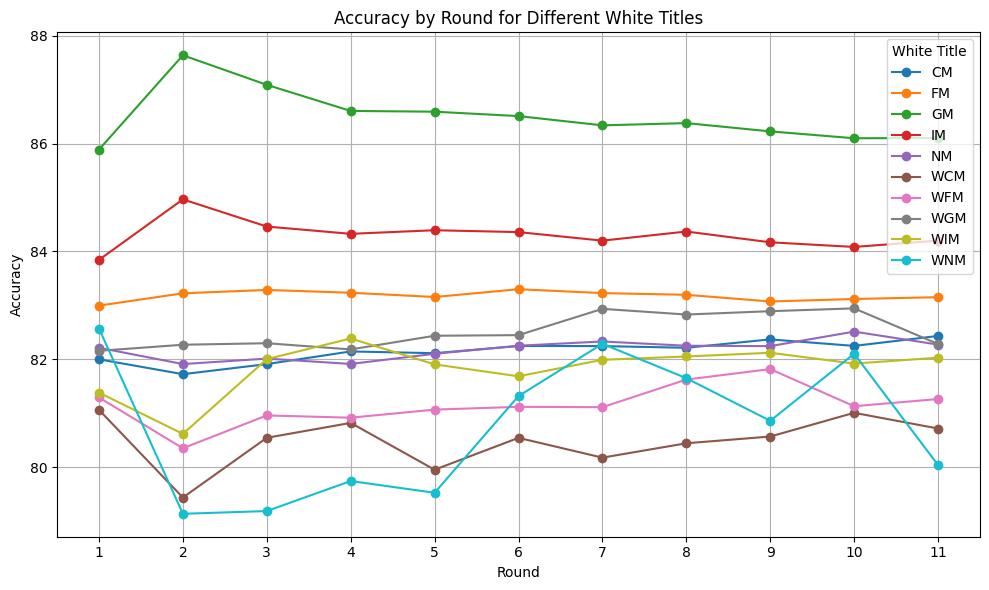

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))

# Loop through each unique white_title and plot its corresponding accuracy
for title in test_by_title['white_title'].unique():
    subset = test_by_title[test_by_title['white_title'] == title]
    plt.plot(subset['round'], subset['accuracy_white'], marker='o', label=title)

# Adding titles and labels
plt.title('Accuracy by Round for Different White Titles')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.xticks(subset['round'].unique())  # Set x-ticks to the unique rounds
plt.legend(title='White Title')
plt.grid()

# Show the plot
plt.tight_layout()
plt.savefig('different_titles', dpi=1000)
plt.show()

In [ ]:
merged_df[merged_df['black_name'] == 'Zhigalko_Sergei']['accuracy_black'].mean()

86.35709803921569

In [ ]:
merged_df['white_name'].value_counts()

,count
white_name,
Zhigalko_Sergei,1377
TigrVShlyape,1277
djano,1241
FairChess_on_YouTube,1237
Oleksandr_Bortnyk,1218
...,...
Checksumme,1
Ruud96,1
Aya5ian,1


In [ ]:
merged_df.to_csv('tournaments_1_261_final_v2.csv')

In [ ]:
final_version = pd.read_csv('tournaments_1_261_final.csv')


In [ ]:
final_version

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,0,Duhless,https://www.chess.com/member/duhless,3071,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419411,89.65,96.40
1,1,Polish_fighter3000,https://www.chess.com/member/polish_fighter3000,3044,GM,FabianoCaruana,https://www.chess.com/member/fabianocaruana,3117,GM,0.5,0.5,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419421,95.22,95.15
2,2,Msb2,https://www.chess.com/member/msb2,3105,GM,GMBenjaminBok,https://www.chess.com/member/gmbenjaminbok,2990,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419427,91.33,84.51
3,3,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3275,GM,sergoy,https://www.chess.com/member/sergoy,2951,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419429,90.18,79.17
4,4,LiemLe,https://www.chess.com/member/liemle,3028,GM,MITerryble,https://www.chess.com/member/miterryble,3032,IM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419435,75.82,82.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433568,433568,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,2262,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,87.60,87.30
433569,433569,HighLawView,https://www.chess.com/member/highlawview,1980,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,82.60,83.10
433570,433570,WonderChampion,https://www.chess.com/member/wonderchampion,2235,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,82.80,83.10
433571,433571,gisela_roque,https://www.chess.com/member/gisela_roque,2099,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,100.00,0.00


In [ ]:
final_version.iloc[268049:, :]

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
268049,268049,JaloliddinIlkhomi,https://www.chess.com/member/jaloliddinilkhomi,2733,FM,tapu2,https://www.chess.com/member/tapu2,2711,IM,0.5,0.5,"Feb 21, 2023, 8:00 AM",7,https://www.chess.com/game/live/70737903599,89.40,89.50
268050,268050,tteshan,https://www.chess.com/member/tteshan,2580,FM,TigrVShlyape,https://www.chess.com/member/tigrvshlyape,2877,GM,0.0,1.0,"Feb 21, 2023, 8:00 AM",7,https://www.chess.com/game/live/70737903603,82.10,89.60
268051,268051,Abund,https://www.chess.com/member/abund,2707,NM,Nf3c5,https://www.chess.com/member/nf3c5,2599,FM,1.0,0.0,"Feb 21, 2023, 8:00 AM",7,https://www.chess.com/game/live/70737903607,84.30,80.70
268052,268052,jens1102,https://www.chess.com/member/jens1102,2556,IM,Chessmissile07,https://www.chess.com/member/chessmissile07,2905,IM,0.5,0.5,"Feb 21, 2023, 8:00 AM",7,https://www.chess.com/game/live/70737903617,89.97,90.56
268053,268053,TERMINATOR_PC,https://www.chess.com/member/terminator_pc,2692,FM,Real_OceanStorm,https://www.chess.com/member/real_oceanstorm,2819,GM,0.5,0.5,"Feb 21, 2023, 8:00 AM",7,https://www.chess.com/game/live/70737903619,86.07,85.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433568,433568,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,2262,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,87.60,87.30
433569,433569,HighLawView,https://www.chess.com/member/highlawview,1980,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,82.60,83.10
433570,433570,WonderChampion,https://www.chess.com/member/wonderchampion,2235,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,82.80,83.10
433571,433571,gisela_roque,https://www.chess.com/member/gisela_roque,2099,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,100.00,0.00


In [ ]:
merged_df.iloc[268049:, :]

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
268049,Chesstiger64,https://www.chess.com/member/chesstiger64,2367,CM,nicolasbatista3,https://www.chess.com/member/nicolasbatista3,2435,FM,1.0,0.0,"Apr 30, 2024, 8:00 AM",1,https://www.chess.com/game/live/108235324925,85.40,81.80
268050,NovakRatko,https://www.chess.com/member/novakratko,2427,CM,Jojo_898,https://www.chess.com/member/jojo_898,2303,WFM,1.0,0.0,"Apr 30, 2024, 8:00 AM",1,https://www.chess.com/game/live/108235324937,76.00,76.10
268051,highlama,https://www.chess.com/member/highlama,2403,FM,ImportedItalianMaple,https://www.chess.com/member/importeditalianmaple,2466,NM,1.0,0.0,"Apr 30, 2024, 8:00 AM",1,https://www.chess.com/game/live/108235324951,95.37,77.81
268052,balack95,https://www.chess.com/member/balack95,2556,CM,DvaHrasta,https://www.chess.com/member/dvahrasta,2536,FM,0.0,1.0,"Apr 30, 2024, 8:00 AM",1,https://www.chess.com/game/live/108235324961,84.90,91.20
268053,KorolDimitriy75,https://www.chess.com/member/koroldimitriy75,2372,NM,Massakru,https://www.chess.com/member/massakru,2454,CM,0.0,1.0,"Apr 30, 2024, 8:00 AM",1,https://www.chess.com/game/live/108235324975,74.70,71.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758979,70.50,79.20
485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758981,84.94,90.58
485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,0.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758983,87.50,79.30
485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,1.0,"Nov 1, 2022, 2:00 PM",11,https://www.chess.com/game/live/61081758985,75.60,86.70


In [ ]:
merged_df.describe()

,white_rating,black_rating,result_white,result_black,round,accuracy_white,accuracy_black
count,433573.000000,433573.000000,433573.000000,433573.000000,433573.000000,424830.000000,422937.000000
mean,2576.987681,2572.871978,0.527419,0.472581,5.742664,83.639598,82.803045
std,289.490743,290.484754,0.476205,0.476205,2.995531,7.624457,7.824414
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2411.000000,2408.000000,0.000000,0.000000,3.000000,78.680000,77.900000
50%,2574.000000,2569.000000,0.500000,0.500000,6.000000,83.990000,83.140000
75%,2751.000000,2746.000000,1.000000,1.000000,8.000000,89.200000,88.300000
max,3319.000000,3319.000000,1.000000,1.000000,11.000000,100.000000,100.000000


In [ ]:
perfomance_by_title['white_title'].unique()

array(['CM', 'FM', 'GM', 'IM', 'NM', 'WCM', 'WFM', 'WGM', 'WIM', 'WNM'],
      dtype=object)

In [ ]:
perfomance_by_title = merged_df[['white_title', 'round', 'accuracy_white']].groupby(['white_title', 'round']).mean().reset_index()


In [ ]:
perfomance_by_title

,white_title,round,accuracy_white
0,CM,1,81.941979
1,CM,2,81.562177
2,CM,3,81.752762
3,CM,4,82.048373
4,CM,5,81.993529
...,...,...,...
105,WNM,7,81.579565
106,WNM,8,81.901379
107,WNM,9,80.527647
108,WNM,10,81.650417


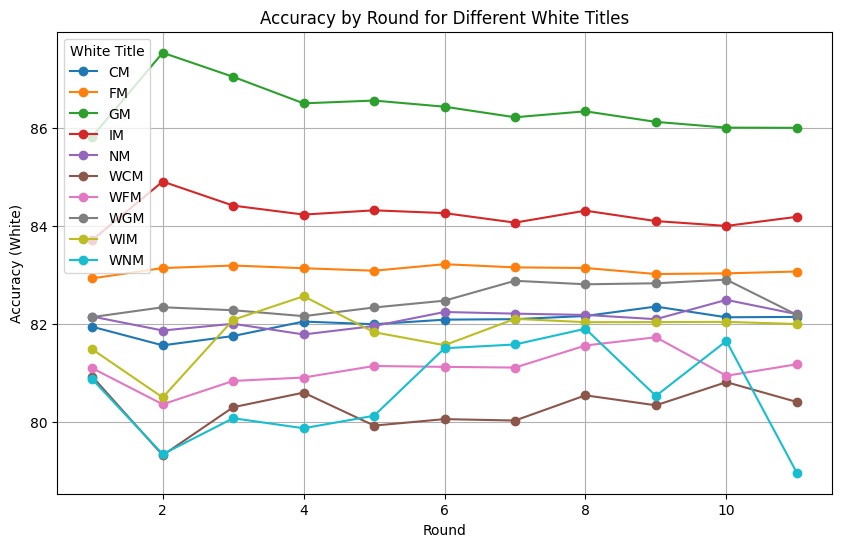

In [ ]:
df_pivot = perfomance_by_title.pivot(index='round', columns='white_title', values='accuracy_white')

# Plot
plt.figure(figsize=(10, 6))
for title in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[title], marker='o', label=title)

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Accuracy (White)')
plt.title('Accuracy by Round for Different White Titles')
plt.legend(title='White Title')
plt.grid(True)

# Show plot
plt.show()

In [ ]:
merged_df['white_name'].value_counts().head(20)

,count
white_name,
Zhigalko_Sergei,1260
TigrVShlyape,1162
FairChess_on_YouTube,1151
djano,1131
Jospem,1125
Oleksandr_Bortnyk,1116
bazar-wokzal,1098
alexrustemov,1097
ural58,1039


In [ ]:
merged_df


,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black
0,Duhless,https://www.chess.com/member/duhless,3071,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419411,89.65,96.40
1,Polish_fighter3000,https://www.chess.com/member/polish_fighter3000,3044,GM,FabianoCaruana,https://www.chess.com/member/fabianocaruana,3117,GM,0.5,0.5,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419421,95.22,95.15
2,Msb2,https://www.chess.com/member/msb2,3105,GM,GMBenjaminBok,https://www.chess.com/member/gmbenjaminbok,2990,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419427,91.33,84.51
3,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3275,GM,sergoy,https://www.chess.com/member/sergoy,2951,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419429,90.18,79.17
4,LiemLe,https://www.chess.com/member/liemle,3028,GM,MITerryble,https://www.chess.com/member/miterryble,3032,IM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419435,75.82,82.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433568,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,2262,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,87.60,87.30
433569,HighLawView,https://www.chess.com/member/highlawview,1980,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,82.60,83.10
433570,WonderChampion,https://www.chess.com/member/wonderchampion,2235,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,82.80,83.10
433571,gisela_roque,https://www.chess.com/member/gisela_roque,2099,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,100.00,0.00


In [ ]:

merged_df['year_month'] = pd.to_datetime(merged_df['date']).dt.to_period('M')
merged_df

<ipython-input-99-012b352f05f7>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['year_month'] = pd.to_datetime(merged_df['date']).dt.to_period('M')


,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,year_month
0,Duhless,https://www.chess.com/member/duhless,3071,GM,Hikaru,https://www.chess.com/member/hikaru,3237,GM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419411,89.65,96.40,2024-05
1,Polish_fighter3000,https://www.chess.com/member/polish_fighter3000,3044,GM,FabianoCaruana,https://www.chess.com/member/fabianocaruana,3117,GM,0.5,0.5,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419421,95.22,95.15,2024-05
2,Msb2,https://www.chess.com/member/msb2,3105,GM,GMBenjaminBok,https://www.chess.com/member/gmbenjaminbok,2990,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419427,91.33,84.51,2024-05
3,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3275,GM,sergoy,https://www.chess.com/member/sergoy,2951,GM,1.0,0.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419429,90.18,79.17,2024-05
4,LiemLe,https://www.chess.com/member/liemle,3028,GM,MITerryble,https://www.chess.com/member/miterryble,3032,IM,0.0,1.0,"May 14, 2024, 2:00 PM",1,https://www.chess.com/game/live/109466419435,75.82,82.34,2024-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433568,Ariadna_Atreides,https://www.chess.com/member/ariadna_atreides,2262,WCM,zurzan,https://www.chess.com/member/zurzan,1958,NM,0.5,0.5,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019803,87.60,87.30,2022-01
433569,HighLawView,https://www.chess.com/member/highlawview,1980,CM,malakismayil,https://www.chess.com/member/malakismayil,2592,WFM,0.0,1.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019805,82.60,83.10,2022-01
433570,WonderChampion,https://www.chess.com/member/wonderchampion,2235,WCM,matkens0123,https://www.chess.com/member/matkens0123,1911,CM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019807,82.80,83.10,2022-01
433571,gisela_roque,https://www.chess.com/member/gisela_roque,2099,WFM,PabloZarnicki,https://www.chess.com/member/pablozarnicki,2578,GM,1.0,0.0,"Jan 25, 2022, 10:00 AM",11,https://www.chess.com/game/live/36879019809,100.00,0.00,2022-01


In [ ]:
merged_df[merged_df['white_name'] == 'Jospem'][['white_name', 'round', 'year_month', 'accuracy_white']].groupby(['white_name', 'year_month', 'round']).mean().reset_index().tail(50)

,white_name,year_month,round,accuracy_white
261,Jospem,2024-01,4,90.860000
262,Jospem,2024-01,5,89.765000
263,Jospem,2024-01,6,84.605000
264,Jospem,2024-01,7,92.523333
265,Jospem,2024-01,8,92.982000
266,Jospem,2024-01,9,82.945714
267,Jospem,2024-01,10,83.210000
268,Jospem,2024-01,11,78.756667
269,Jospem,2024-02,1,90.465000
270,Jospem,2024-02,2,79.660000


# Gender analysis on final TT data

In [ ]:
import pandas as pd
tournaments = pd.read_csv('tournaments_1_261_final_v3.csv',sep=',').iloc[:, 2:]
tournaments.head()

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_final_score,black_final_score
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37,0.0,0.0
1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140781,91.75,81.10,1.0,0.0
2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140787,72.16,63.46,1.0,0.0
3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140789,90.36,81.15,1.0,0.0
4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140791,80.20,84.18,0.0,0.0


In [ ]:
tournaments['white_female'] = [1 if 'W' in x else 0 for x in tournaments['white_title']]
tournaments['black_female'] = [1 if 'W' in x else 0 for x in tournaments['black_title']]
tournaments.head()

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_final_score,black_final_score,white_female,black_female
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140775,82.86,89.37,0.0,0.0,0,0
1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140781,91.75,81.10,1.0,0.0,0,0
2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140787,72.16,63.46,1.0,0.0,0,0
3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140789,90.36,81.15,1.0,0.0,0,0
4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,"Feb 14, 2023, 2:00 PM",1,https://www.chess.com/game/live/70158140791,80.20,84.18,0.0,0.0,0,0


In [ ]:
players_gender = tournaments.groupby('white_name')[['white_female', 'white_rating', 'black_rating']].mean().reset_index()
players_gender.value_counts('white_female')

,count
white_female,
0.000000,5169
1.000000,601
0.026403,1
0.065789,1
0.071429,1
0.072072,1
0.075269,1


In [ ]:
players_gender = players_gender[(players_gender['white_name']!='Barbus89') & (players_gender['white_name']!='GM4L')& (players_gender['white_name']!='IMAghasiyevKamal') & (players_gender['white_name']!='anon481216') & (players_gender['white_name']!='anon6121824')]


In [ ]:
players_gender['white_female'].value_counts(normalize=True)

,proportion
white_female,
0.0,0.895841
1.0,0.104159


In [ ]:
players_gender['white_rating'].quantile(0.15)

2243.0

In [ ]:
players_gender[players_gender['white_rating'] <= 2243]['white_female'].value_counts(normalize=True)

,proportion
white_female,
0.0,0.713464
1.0,0.286536


In [ ]:
worst_15 = tournaments[tournaments['white_rating'] <= 2243]

df_2 = worst_15.groupby(['round', 'white_female'])['accuracy_white'].mean().reset_index()
# Separate data for male and female
female_data_2 = df_2[df_2['white_female'] == 1]
male_data_2 = df_2[df_2['white_female'] == 0]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(female_data_2['round'], female_data_2['accuracy_white'], label='Female', marker='o')
plt.plot(male_data_2['round'], male_data_2['accuracy_white'], label='Male', marker='o')
plt.title('Average Accuracy per Round for Males and Females (Worst 15%)')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
black_num_games = tournaments.groupby(['black_female', 'round'])['date'].count().reset_index().rename(columns={'date':'num_games'})

In [ ]:
total_round_games = tournaments.groupby(['white_female', 'round'])['date'].count().reset_index().rename(columns={'date':'num_games'})

#total_round_games['num_games'] += black_num_games['num_games']
total_round_games

,white_female,round,num_games
0,0,1,29634
1,0,2,49409
2,0,3,50165
3,0,4,48706
4,0,5,47015
5,0,6,43786
6,0,7,41782
7,0,8,39283
8,0,9,36827
9,0,10,33339


<ipython-input-33-30128abb3c0a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_data['normalized_games'] = female_data['num_games'] / female_data[female_data['round'] == 4]['num_games'].values[0]
<ipython-input-33-30128abb3c0a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_data['normalized_games'] = male_data['num_games'] / male_data[male_data['round'] == 4]['num_games'].values[0]


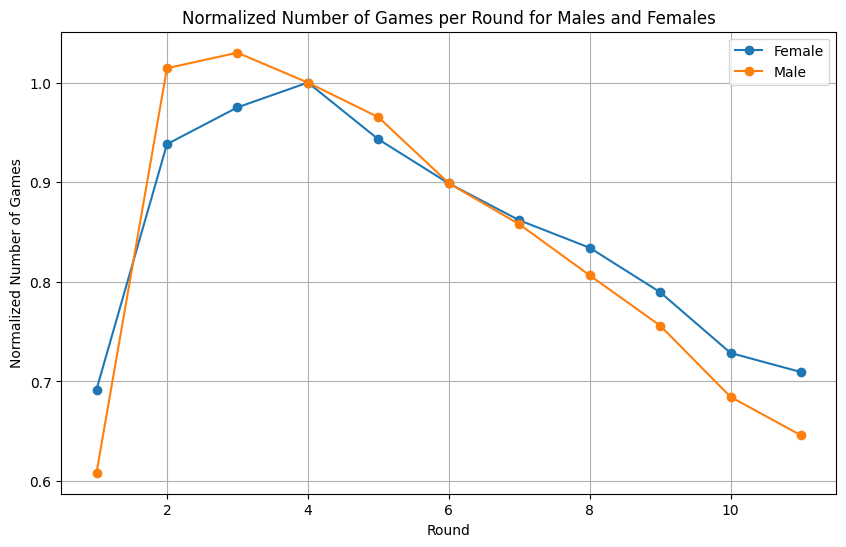

In [ ]:
import matplotlib.pyplot as plt

female_data = total_round_games[total_round_games['white_female'] == 1]
male_data = total_round_games[total_round_games['white_female'] == 0]

# Normalize num_games for both female and male data based on the second round
female_data['normalized_games'] = female_data['num_games'] / female_data[female_data['round'] == 4]['num_games'].values[0]
male_data['normalized_games'] = male_data['num_games'] / male_data[male_data['round'] == 4]['num_games'].values[0]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(female_data['round'], female_data['normalized_games'], label='Female', marker='o')
plt.plot(male_data['round'], male_data['normalized_games'], label='Male', marker='o')
plt.title('Normalized Number of Games per Round for Males and Females')
plt.xlabel('Round')
plt.ylabel('Normalized Number of Games')
plt.legend()
plt.grid(True)
plt.savefig('number_of_games', dpi=1000)
plt.show()

In [ ]:
tournaments['round'].value_counts()

,count
round,
3,53729
2,52838
4,52361
5,50462
6,47071
7,44932
8,42332
9,39713
10,36002


In [ ]:
tournaments.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'white_name', 'white_link',
       'white_rating', 'white_title', 'black_name', 'black_link',
       'black_rating', 'black_title', 'result_white', 'result_black', 'date',
       'round', 'game_link', 'accuracy_white', 'accuracy_black',
       'white_gender', 'black_gender', 'final_score_white',
       'final_score_black', 'white_could_win', 'black_could_win',
       'white_could_win_05', 'black_could_win_05', 'white_leader',
       'black_leader', 'white_could_win_prizes', 'black_could_win_prizes',
       'white_could_win_prizes_05', 'black_could_win_prizes_05',
       'black_female', 'white_female'],
      dtype='object')

In [ ]:
white_games = tournaments[['white_name', 'white_rating', 'white_title', 'accuracy_white', 'white_female', 'round', 'date', 'black_rating', 'result_white', 'white_could_win', 'white_could_win_05', 'white_leader', 'white_could_win_prizes']].rename(columns={'white_name': 'player_name',	'white_rating': 'player_rating', 'white_title': 'player_title', 'accuracy_white': 'player_accuracy','white_female': 'is_female', 'black_rating': 'opponent_rating', 'result_white': 'player_result', 'white_could_win': 'could_win', 'white_could_win_05': 'could_win_05', 'white_leader': 'leader', 'white_could_win_prizes': 'could_win_prizes'})
white_games['is_white'] = 1
black_games = tournaments[['black_name', 'black_rating', 'black_title', 'accuracy_black', 'black_female', 'round', 'date', 'white_rating', 'result_black', 'black_could_win', 'black_could_win_05', 'black_leader', 'black_could_win_prizes']].rename(columns={'black_name': 'player_name',	'black_rating': 'player_rating', 'black_title': 'player_title', 'accuracy_black': 'player_accuracy',	'black_female': 'is_female', 'white_rating': 'opponent_rating', 'result_black': 'player_result', 'black_could_win': 'could_win', 'black_could_win_05': 'could_win_05', 'black_leader': 'leader', 'black_could_win_prizes': 'could_win_prizes'})
black_games['is_white'] = 0

players_regression_data = pd.concat([white_games, black_games]).reset_index(drop=True)

In [ ]:
players_regression_data.to_csv("players_regression_data_3.csv")

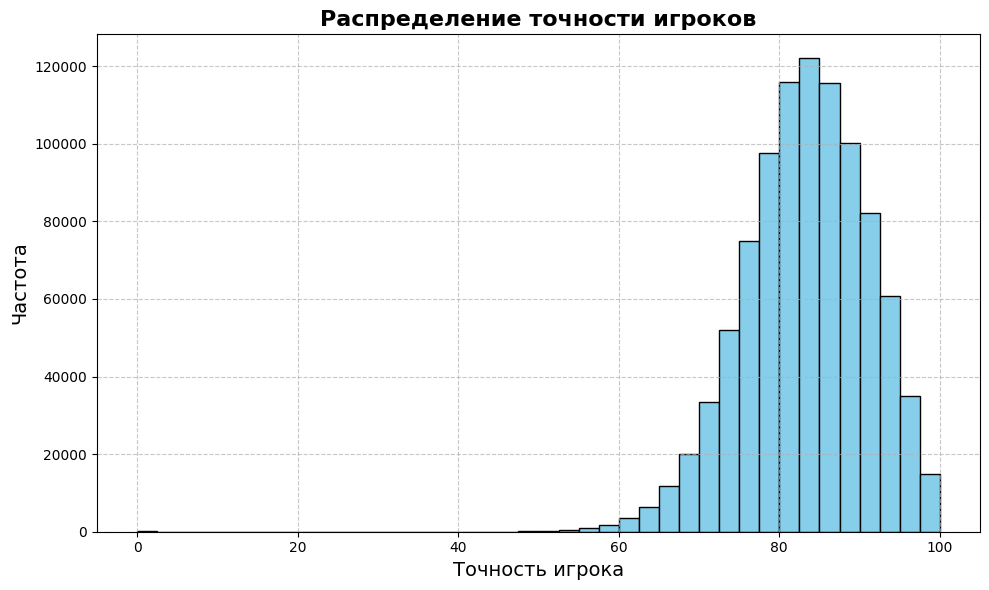

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))  # Задаём размер фигуры

players_regression_data['player_accuracy'].hist(
    bins=40,
    ax=ax,
    color='skyblue',      # цвет гистограммы
    edgecolor='black'     # цвет границ столбцов
)

# Добавляем заголовок и подписи осей
ax.set_title('Распределение точности игроков', fontsize=16, fontweight='bold')
ax.set_xlabel('Точность игрока', fontsize=14)
ax.set_ylabel('Частота', fontsize=14)

# Включаем сетку
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()  # Оптимизация расположения элементов
plt.savefig('accuracy_distribution', dpi=1000)
plt.show()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf




players_regression_data['round'] = pd.Categorical(players_regression_data['round'], categories=list(range(1, 12)), ordered=True)
players_regression_data = pd.get_dummies(players_regression_data, columns=['round'], drop_first=True)  # Dropping round 1 as baseline

# Construct the regression formula
# player_accuracy ~ round dummies + is_white + is_female + interactions (is_female * round dummies) + player_name dummies
formula = "player_accuracy ~ is_white + is_female + " + " + ".join([f"round_{i}" for i in range(2, 12)]) + " + " + \
          " + ".join([f"is_female:round_{i}" for i in range(2, 12)]) + " + C(player_name)"

# Fit the regression model
model = smf.ols(formula=formula, data=players_regression_data).fit()

# Print the summary of the regression
model_summary = model.summary()
model_summary

In [ ]:
"player_accuracy ~ is_white + is_female + " + " + ".join([f"round_{i}" for i in range(2, 12)]) + " + " + \
          " + ".join([f"is_female:round_{i}" for i in range(2, 12)]) + " + C(player_name)"

'player_accuracy ~ is_white + is_female + round_2 + round_3 + round_4 + round_5 + round_6 + round_7 + round_8 + round_9 + round_10 + round_11 + is_female:round_2 + is_female:round_3 + is_female:round_4 + is_female:round_5 + is_female:round_6 + is_female:round_7 + is_female:round_8 + is_female:round_9 + is_female:round_10 + is_female:round_11 + C(player_name)'

In [ ]:
female_data = players_regression_data[players_regression_data['is_female'] == 1]

female_data.groupby('round')['player_accuracy'].mean().reset_index()

,player_accuracy
round,
1,80.912353
2,80.300606
3,80.748226
4,80.894369
5,80.836619
6,80.847265
7,80.971559
8,81.089685
9,81.289332


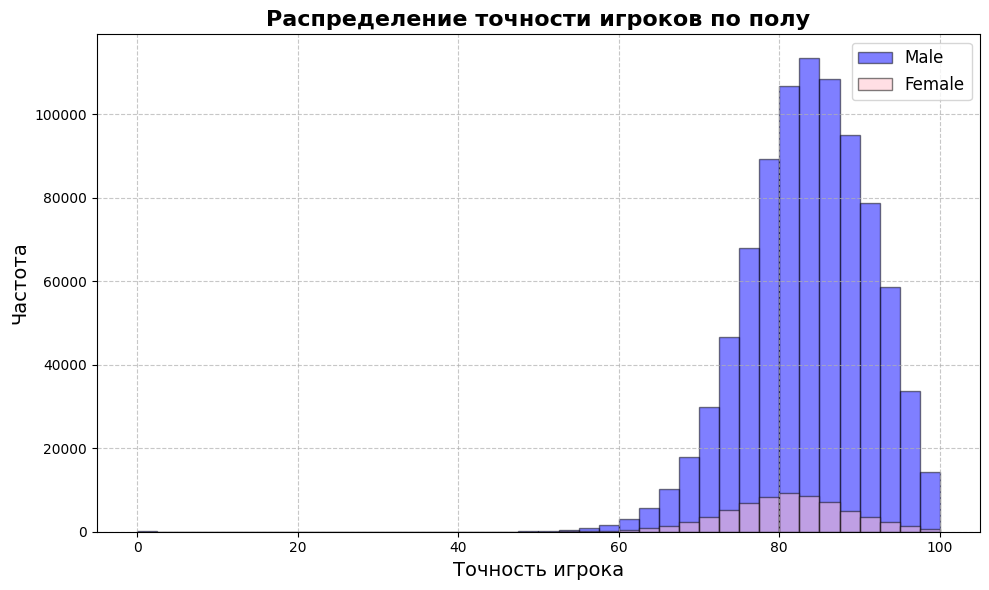

In [ ]:
import matplotlib.pyplot as plt

# Разделяем данные на две группы
female_data = players_regression_data.loc[players_regression_data['is_female'] == 1, 'player_accuracy']
male_data = players_regression_data.loc[players_regression_data['is_female'] == 0, 'player_accuracy']

fig, ax = plt.subplots(figsize=(10, 6))

# Строим гистограммы
ax.hist(male_data, bins=40, alpha=0.5, color='blue', edgecolor='black', label='Male')
ax.hist(female_data, bins=40, alpha=0.5, color='pink', edgecolor='black', label='Female')

# Добавляем заголовок и подписи осей
ax.set_title('Распределение точности игроков по полу', fontsize=16, fontweight='bold')
ax.set_xlabel('Точность игрока', fontsize=14)
ax.set_ylabel('Частота', fontsize=14)

# Включаем сетку
ax.grid(True, linestyle='--', alpha=0.7)

# Добавляем легенду
ax.legend(fontsize=12)
plt.savefig('gender_accuracy_distribution', dpi=1000)
plt.tight_layout()
plt.show()

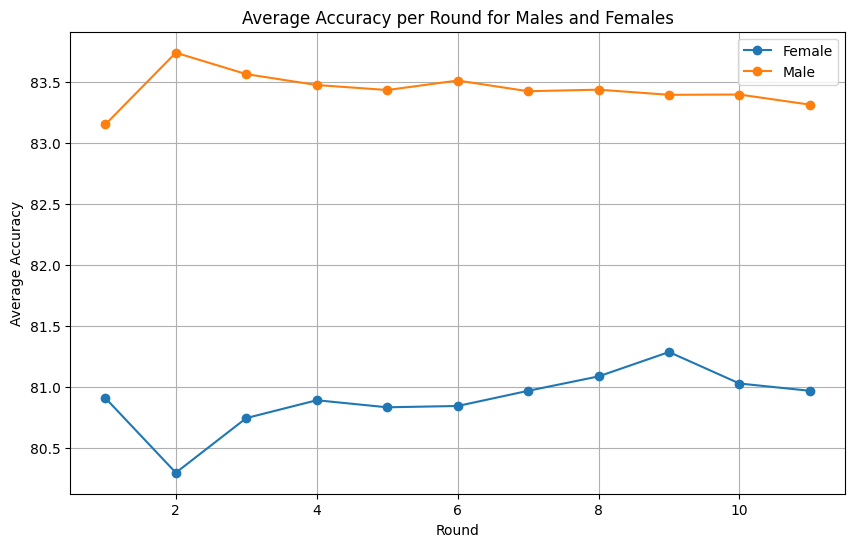

In [ ]:
import matplotlib.pyplot as plt

female_data = players_regression_data[players_regression_data['is_female'] == 1]
male_data = players_regression_data[players_regression_data['is_female'] == 0]

# Normalize num_games for both female and male data based on the second round
female_data = female_data.groupby('round')['player_accuracy'].mean().reset_index()
male_data = male_data.groupby('round')['player_accuracy'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(female_data['round'], female_data['player_accuracy'], label='Female', marker='o')
plt.plot(male_data['round'], male_data['player_accuracy'], label='Male', marker='o')
plt.title('Average Accuracy per Round for Males and Females')
plt.xlabel('Round')
plt.ylabel('Average Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_gender', dpi=1000)
plt.show()

In [ ]:
players_regression_data[players_regression_data['is_female'] == 1]['round'].value_counts()

,count
round,
3,7258
4,7182
5,7001
2,6829
6,6646
7,6439
8,6129
9,5889
10,5437


# Dagaev tests

In [ ]:
import pandas as pd
tournaments = pd.read_csv('tournaments_1_261_final_v5.csv').iloc[:, 1:]

In [ ]:
tournaments = tournaments.rename(columns={'final_score': 'final_score_black'})

In [ ]:
tournaments = tournaments.drop(columns=['white_final_score', 'black_final_score'])

In [ ]:
tournaments

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,...,round,game_link,accuracy_white,accuracy_black,white_final_score,black_final_score,white_gender,black_gender,final_score_white,final_score
0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,1.0,...,1,https://www.chess.com/game/live/70158140775,82.86,89.37,0.0,0.0,0,0,0.0,1.0
1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,0.0,...,1,https://www.chess.com/game/live/70158140781,91.75,81.10,1.0,0.0,0,0,1.0,0.0
2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,0.0,...,1,https://www.chess.com/game/live/70158140787,72.16,63.46,1.0,0.0,0,0,1.0,0.0
3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,0.0,...,1,https://www.chess.com/game/live/70158140789,90.36,81.15,1.0,0.0,0,0,1.0,0.0
4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,1.0,...,1,https://www.chess.com/game/live/70158140791,80.20,84.18,0.0,0.0,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,1.0,...,11,https://www.chess.com/game/live/61081758979,70.50,79.20,2.0,0.0,0,0,2.0,3.0
485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,1.0,...,11,https://www.chess.com/game/live/61081758981,84.94,90.58,0.0,4.0,0,0,2.0,4.0
485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,0.0,...,11,https://www.chess.com/game/live/61081758983,87.50,79.30,2.0,0.0,1,0,2.0,2.5
485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,1.0,...,11,https://www.chess.com/game/live/61081758985,75.60,86.70,0.0,2.5,1,0,1.0,2.5


In [ ]:
tournaments[tournaments['final_score_black'] == 11]

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_gender,black_gender,final_score_white,final_score_black
232922,DenLaz,https://www.chess.com/member/denlaz,3170,GM,mishanick,https://www.chess.com/member/mishanick,3161,GM,0.0,1.0,"Jun 4, 2024, 8:00 AM",11,https://www.chess.com/game/live/111258681721,76.67,81.86,0,0,8.0,11.0
373311,Hikaru,https://www.chess.com/member/hikaru,3223,GM,MagnusCarlsen,https://www.chess.com/member/magnuscarlsen,3311,GM,0.0,1.0,"Jul 4, 2023, 2:00 PM",11,https://www.chess.com/game/live/82249833967,79.90,91.25,0,0,7.5,11.0


In [ ]:
tournaments[(tournaments['white_name'] == 'Hikaru') & (tournaments['date'] == 'Feb 14, 2023, 2:00 PM')]

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,date,round,game_link,accuracy_white,accuracy_black,white_gender,black_gender,final_score_white,final_score_black
249,Hikaru,https://www.chess.com/member/hikaru,3232,GM,NateSolon,https://www.chess.com/member/natesolon,2597,FM,0.0,1.0,"Feb 14, 2023, 2:00 PM",3,https://www.chess.com/game/live/70151655449,85.52,90.24,0,0,2.0,2.0
596,Hikaru,https://www.chess.com/member/hikaru,3232,GM,The_Machine04,https://www.chess.com/member/the_machine04,2824,IM,1.0,0.0,"Feb 14, 2023, 2:00 PM",5,https://www.chess.com/game/live/70152918371,84.03,77.02,0,0,4.0,2.0
1026,Hikaru,https://www.chess.com/member/hikaru,3235,GM,Cayse,https://www.chess.com/member/cayse,2817,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",8,https://www.chess.com/game/live/70155230413,89.32,78.09,0,0,6.5,4.5
1147,Hikaru,https://www.chess.com/member/hikaru,3235,GM,Byniolus,https://www.chess.com/member/byniolus,2772,GM,1.0,0.0,"Feb 14, 2023, 2:00 PM",9,https://www.chess.com/game/live/70155865221,88.43,82.79,0,0,7.5,6.0
1360,Hikaru,https://www.chess.com/member/hikaru,3235,GM,MITerryble,https://www.chess.com/member/miterryble,3011,IM,1.0,0.0,"Feb 14, 2023, 2:00 PM",11,https://www.chess.com/game/live/70157544367,79.41,76.81,0,0,9.5,7.5


## T11+ and T11-

In [ ]:
white_final = pd.DataFrame()
black_final = pd.DataFrame()

for tournament in tournaments['date'].unique():
  maximum_score = max(tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)][['final_score_white', 'final_score_black']].max())
  could_win_white = [1 if x >= maximum_score - 1 else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['final_score_white']]
  could_win_black = [1 if x >= maximum_score - 1 else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['final_score_black']]
  nick_name_white = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['white_name']]
  nick_name_black = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['black_name']]

  white_temp = pd.DataFrame({'white_name': nick_name_white, 'date': tournament, 'white_could_win': could_win_white}).drop_duplicates()
  white_final = pd.concat([white_final, white_temp], axis=0)
  black_temp = pd.DataFrame({'black_name': nick_name_black, 'date': tournament, 'black_could_win': could_win_black}).drop_duplicates()
  black_final= pd.concat([black_final, black_temp], axis=0)

KeyboardInterrupt: 

In [ ]:
tournaments_new = tournaments.merge(white_final, on = ['white_name', 'date'], how='left').merge(black_final, on = ['black_name', 'date'], how='left')
tournaments_new['white_could_win'] = tournaments_new['white_could_win'].fillna(0)
tournaments_new['black_could_win'] = tournaments_new['black_could_win'].fillna(0)
tournaments_new

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,...,final_score_white,final_score_black,white_could_win_05,black_could_win_05,white_leader,black_leader,white_could_win_prizes,black_could_win_prizes,white_could_win,black_could_win
0,0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485652,485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,...,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485653,485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,...,2.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485654,485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,...,1.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
tournaments_new = tournaments.copy()

### Could win (x >= max - 1)

In [ ]:
could_not_win = pd.concat([tournaments_new[tournaments_new['white_could_win'] == 0][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_could_win'] == 0][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_not_win

,round,accuracy
0,1,82.844780
1,2,83.447347
2,3,83.304354
3,4,83.237406
4,5,83.189526
5,6,83.252377
6,7,83.168891
7,8,83.180110
8,9,83.194218
9,10,83.008305


In [ ]:

could_win = pd.concat([tournaments_new[tournaments_new['white_could_win'] == 1][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_could_win'] == 1][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_win

,round,accuracy
0,1,87.927387
1,2,88.419445
2,3,88.304851
3,4,87.530638
4,5,87.669987
5,6,87.824067
6,7,87.769238
7,8,87.692311
8,9,88.148000
9,10,87.992864


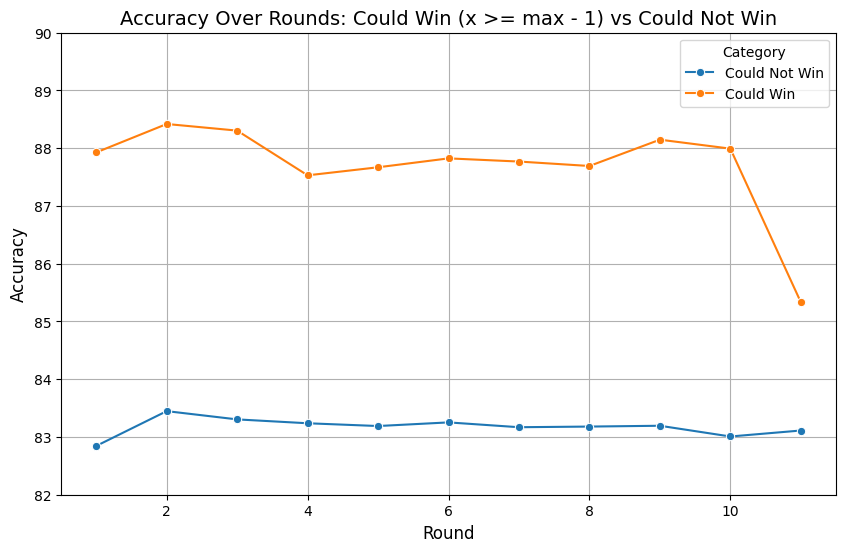

In [ ]:

# Adding a column to differentiate datasets
could_not_win["Category"] = "Could Not Win"
could_win["Category"] = "Could Win"

# Combine both datasets
combined_data = pd.concat([could_not_win, could_win])

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_data, x="round", y="accuracy", hue="Category", marker="o")
plt.title("Accuracy Over Rounds: Could Win (x >= max - 1) vs Could Not Win", fontsize=14)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Category")
plt.grid(True)
plt.ylim(82, 90)
plt.savefig('could_win_one_point', dpi=1000)
plt.show()

### Another specification: Could win (x >= max - 0.5)

In [ ]:
tournaments = pd.read_csv('tournaments_1_261_final_v5.csv')

In [ ]:
could_not_win = pd.concat([tournaments_new[tournaments_new['white_could_win_05'] == 0][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_could_win_05'] == 0][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_not_win


,round,accuracy
0,1,82.912060
1,2,83.485019
2,3,83.345272
3,4,83.270959
4,5,83.227003
5,6,83.295380
6,7,83.211526
7,8,83.228395
8,9,83.219269
9,10,83.121625


In [ ]:
could_win = pd.concat([tournaments_new[tournaments_new['white_could_win_05'] == 1][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_could_win_05'] == 1][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_win

,round,accuracy
0,1,88.816974
1,2,88.764101
2,3,88.594202
3,4,87.847951
4,5,88.063875
5,6,87.800111
6,7,88.357970
7,8,88.129297
8,9,88.473406
9,10,88.612285


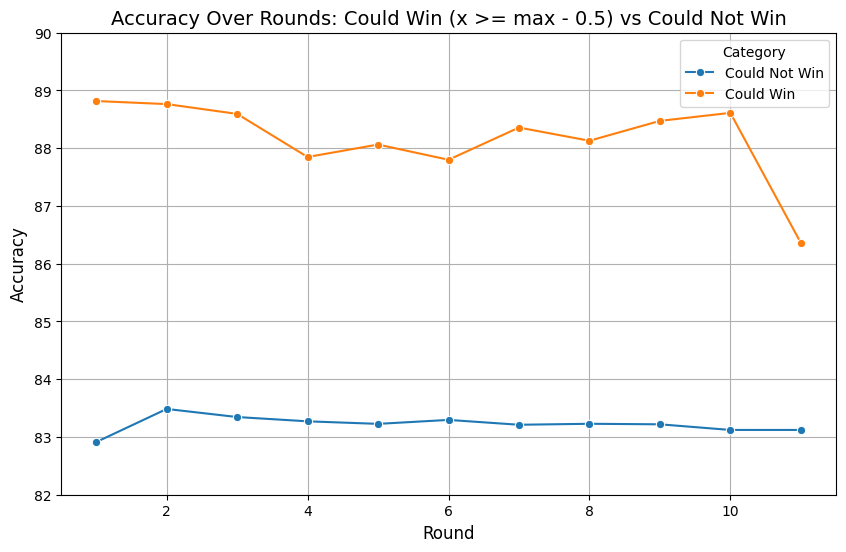

In [ ]:

# Adding a column to differentiate datasets
could_not_win["Category"] = "Could Not Win"
could_win["Category"] = "Could Win"

# Combine both datasets
combined_data = pd.concat([could_not_win, could_win])

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_data, x="round", y="accuracy", hue="Category", marker="o")
plt.title("Accuracy Over Rounds: Could Win (x >= max - 0.5) vs Could Not Win", fontsize=14)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Category")
plt.ylim(82, 90)
plt.grid(True)
plt.savefig('could_win_zero_five_points', dpi=1000)
plt.show()


## Leaders

In [ ]:
tournaments[['final_score_white', 'final_score_black']].nlargest(5)

,0
final_score_white,11.0
final_score_black,11.0


In [ ]:
white_final = pd.DataFrame()
black_final = pd.DataFrame()

for tournament in tournaments['date'].unique():
  maximum_score = max(tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)][['final_score_white', 'final_score_black']].max())
  leader_white = [1 if x == maximum_score else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['final_score_white']]
  leader_black = [1 if x == maximum_score else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['final_score_black']]
  nick_name_white = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['white_name']]
  nick_name_black = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['black_name']]

  white_temp = pd.DataFrame({'white_name': nick_name_white, 'date': tournament, 'white_leader': leader_white}).drop_duplicates()
  white_final = pd.concat([white_final, white_temp], axis=0)
  black_temp = pd.DataFrame({'black_name': nick_name_black, 'date': tournament, 'black_leader': leader_black}).drop_duplicates()
  black_final= pd.concat([black_final, black_temp], axis=0)

In [ ]:
tournaments_new = tournaments_new.merge(white_final, on = ['white_name', 'date'], how='left').merge(black_final, on = ['black_name', 'date'], how='left')
tournaments_new['white_leader'] = tournaments_new['white_leader'].fillna(0)
tournaments_new['black_leader'] = tournaments_new['black_leader'].fillna(0)
tournaments_new

,Unnamed: 0.1,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,...,white_could_win_05,black_could_win_05,white_leader,black_leader,white_could_win_prizes,black_could_win_prizes,white_could_win_prizes_05,black_could_win_prizes_05,black_female,white_female
0,0,0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0
1,1,1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
3,3,3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
4,4,4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,485651,485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
485652,485652,485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
485653,485653,485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
485654,485654,485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1


In [ ]:
not_leader = pd.concat([tournaments_new[tournaments_new['white_leader'] == 0][['round','accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_leader'] == 0][['round',  'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
not_leader

,round,accuracy
0,1,82.968793
1,2,83.506817
2,3,83.363630
3,4,83.290478
4,5,83.243437
5,6,83.312601
6,7,83.237413
7,8,83.252020
8,9,83.221892
9,10,83.211936


In [ ]:
leader = pd.concat([tournaments_new[tournaments_new['white_leader'] == 1][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments_new[tournaments_new['black_leader'] == 1][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
leader

,round,accuracy
0,1,89.786020
1,2,88.851909
2,3,88.517711
3,4,87.870000
4,5,88.699095
5,6,88.694145
6,7,88.231822
7,8,89.045000
8,9,88.922481
9,10,89.615100


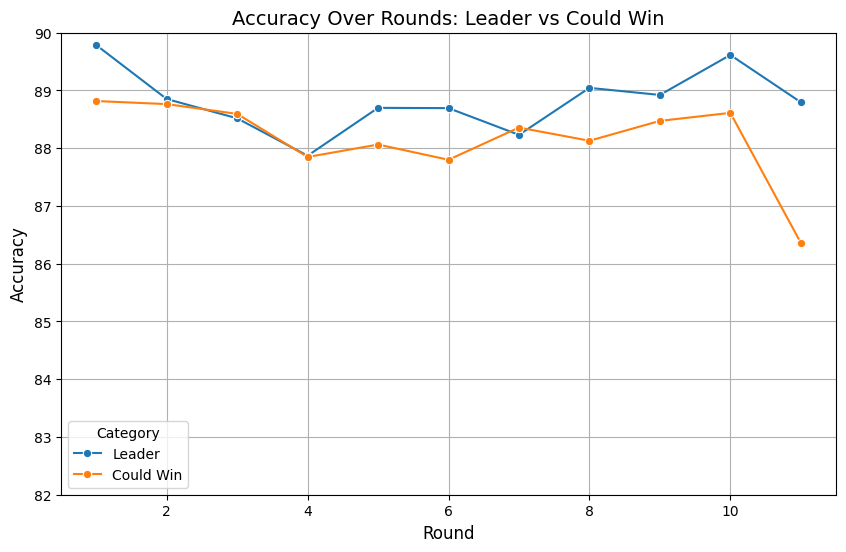

In [ ]:
leader["Category"] = ["Leader"] * 11
could_win["Category"] = ["Could Win"] * 11

combined_leader_data = pd.concat([leader, could_win])
combined_leader_data.reset_index(drop=True, inplace=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_leader_data, x="round", y="accuracy", hue="Category", marker="o")
plt.title("Accuracy Over Rounds: Leader vs Could Win", fontsize=14)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Category")
plt.grid(True)
plt.ylim(82, 90)
plt.savefig('leader_vs_could_win.png', dpi=1000)
plt.show()

In [ ]:
tournaments_new.to_csv('tournaments_1_261_final_v5.csv')

,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,...,final_score_white,final_score_black,white_could_win_05,black_could_win_05,white_leader,black_leader,white_could_win_prizes,black_could_win_prizes,white_could_win,black_could_win
0,0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485652,485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,0.0,...,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485653,485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,1.0,...,2.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485654,485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,0.0,...,1.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Could win prizes

In [ ]:
tournaments = pd.read_csv('tournaments_1_261_final_v6.csv')

In [ ]:
(
    tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]
    [['final_score_white', 'final_score_black']]
    .stack()
    .sort_values(ascending=False)
    .iloc[0]
)

9.5

In [ ]:
tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)][['final_score_white', 'final_score_black']].nlargest(5, columns=['final_score_white'])

,final_score_white,final_score_black
485564,9.5,9.0
485563,9.0,9.5
485568,8.0,9.0
485566,8.0,8.0
485567,8.0,8.0


In [ ]:
max(tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['final_score_white'].nlargest(5).iloc[-1],
                   tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]['final_score_black'].nlargest(5).iloc[-1])

8.5

In [ ]:
white_final = pd.DataFrame()
black_final = pd.DataFrame()

for tournament in tournaments['date'].unique():
  fifth_highest_score = (
    tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 11)]
    [['final_score_white', 'final_score_black']]
    .stack()
    .sort_values(ascending=False)
    .iloc[69]
)

  could_win_white = [1 if x >= fifth_highest_score - 1 else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['final_score_white']]
  could_win_black = [1 if x >= fifth_highest_score - 1 else 0 for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['final_score_black']]
  nick_name_white = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['white_name']]
  nick_name_black = [x for x in tournaments[(tournaments['date'] == tournament) & (tournaments['round'] == 10)]['black_name']]

  white_temp = pd.DataFrame({'white_name': nick_name_white, 'date': tournament, 'white_test_20': could_win_white}).drop_duplicates()
  white_final = pd.concat([white_final, white_temp], axis=0)
  black_temp = pd.DataFrame({'black_name': nick_name_black, 'date': tournament, 'black_test_20': could_win_black}).drop_duplicates()
  black_final= pd.concat([black_final, black_temp], axis=0)

In [ ]:
tournaments = tournaments.drop(columns=['white_test_20', 'black_test_20']).merge(white_final, on = ['white_name', 'date'], how='left').merge(black_final, on = ['black_name', 'date'], how='left')
tournaments['white_test_20'] = tournaments['white_test_20'].fillna(0)
tournaments['black_test_20'] = tournaments['black_test_20'].fillna(0)
tournaments

,Unnamed: 0.1,Unnamed: 0,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,...,white_could_beat_top_10,black_could_beat_top_10,white_could_beat_top_15,black_could_beat_top_15,white_could_beat_top_20_y,black_could_beat_top_20_y,white_could_beat_top_20,black_could_beat_top_20,white_test_20,black_test_20
0,0,0,Oleksandr_Bortnyk,https://www.chess.com/member/oleksandr_bortnyk,3130,GM,Hikaru,https://www.chess.com/member/hikaru,3229,GM,...,0.0,1.0,0.0,1.0,NaN,1.0,0.0,1.0,0.0,1.0
1,1,1,FairChess_on_YouTube,https://www.chess.com/member/fairchess_on_youtube,3136,GM,Msb2,https://www.chess.com/member/msb2,3107,GM,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,2,2,BogdanDeac,https://www.chess.com/member/bogdandeac,3066,GM,mishanick,https://www.chess.com/member/mishanick,3040,GM,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,3,3,Njal28,https://www.chess.com/member/njal28,2958,GM,greekplayer1,https://www.chess.com/member/greekplayer1,2760,FM,...,1.0,0.0,1.0,0.0,1.0,NaN,1.0,0.0,1.0,0.0
4,4,4,Baku_Boulevard,https://www.chess.com/member/baku_boulevard,3103,GM,AlexanderL,https://www.chess.com/member/alexanderl,2888,GM,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485651,485651,485651,Doudou2015,https://www.chess.com/member/doudou2015,2190,CM,Fraler15,https://www.chess.com/member/fraler15,2384,FM,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
485652,485652,485652,Amurath,https://www.chess.com/member/amurath,2239,FM,giomar27,https://www.chess.com/member/giomar27,2386,CM,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
485653,485653,485653,RebecaJimnz,https://www.chess.com/member/rebecajimnz,2262,WFM,frequentblunders,https://www.chess.com/member/frequentblunders,2226,NM,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
485654,485654,485654,Chess4always,https://www.chess.com/member/chess4always,1979,WFM,TheMagician,https://www.chess.com/member/themagician,2228,FM,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0


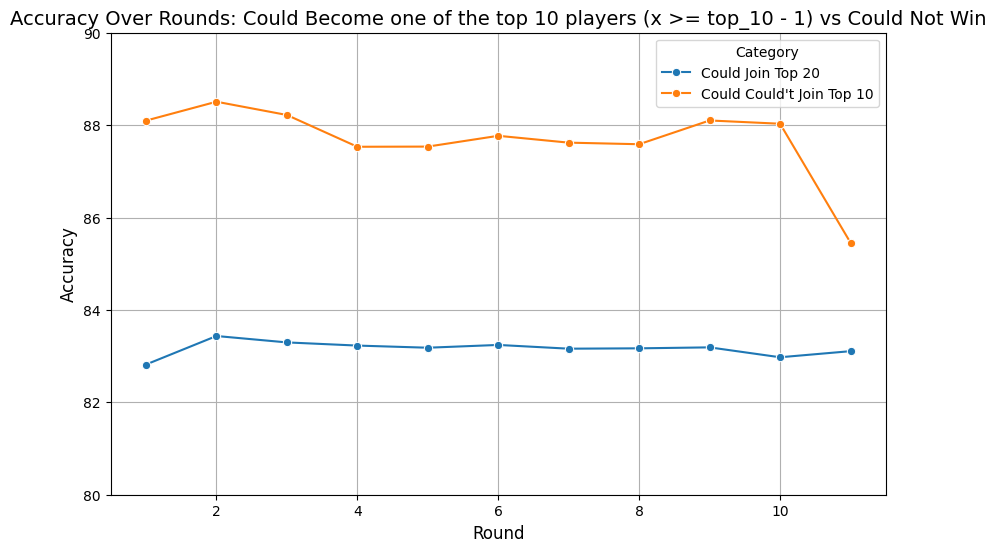

In [ ]:
could_not_win = pd.concat([tournaments[tournaments['white_test_20'] == 0][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments[tournaments['black_test_20'] == 0][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_not_win

could_win = pd.concat([tournaments[tournaments['white_test_20'] == 1][['round', 'accuracy_white']].rename(columns={'accuracy_white': 'accuracy', 'white_gender': 'gender'}),
           tournaments[tournaments['black_test_20'] == 1][['round', 'accuracy_black']].rename(columns={'accuracy_black': 'accuracy', 'black_gender': 'gender'})], axis=0).groupby(['round']).mean().reset_index()
could_win
# Adding a column to differentiate datasets
could_not_win["Category"] = "Could Join Top 20"
could_win["Category"] = "Could Could't Join Top 10"

# Combine both datasets
combined_data = pd.concat([could_not_win, could_win])

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_data, x="round", y="accuracy", hue="Category", marker="o")
plt.title("Accuracy Over Rounds: Could Become one of the top 10 players (x >= top_10 - 1) vs Could Not Win", fontsize=14)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Category")
plt.ylim(80, 90)
plt.grid(True)
plt.savefig('could_win_prizes_zero_five_points', dpi=1000)
plt.show()


In [ ]:
tournaments_1_261_final_v6.csv

## regression analysis v2

In [ ]:
regressions = pd.concat([tournaments_new[['white_name', 'white_rating', 'white_title', 'result_white', 'accuracy_white', 'final_score_white', 'white_could_win', 'white_leader', 'date', 'round', 'black_rating']].rename(
    columns={'white_name': "name", 'white_rating': 'rating', 'white_title': 'title', 'result_white': 'result', 'accuracy_white': 'accuracy', 'final_score_white': 'final_score', 'white_could_win': 'could_win', 'white_leader': 'leader', 'black_rating': 'opponent_rating'}
), tournaments_new[['black_name', 'black_rating', 'black_title', 'result_black', 'accuracy_black', 'final_score_black', 'black_could_win', 'black_leader', 'date', 'round', 'white_rating']].rename(
    columns={'black_name': 'name', 'black_rating': 'rating', 'black_title': 'title', 'result_black': 'result', 'accuracy_black': 'accuracy', 'final_score_black': 'final_score', 'black_could_win': 'could_win', 'black_leader': 'leader', 'white_rating': 'opponent_rating'}
)], axis=0).reset_index(drop=True)
regressions['round_11'] = [1 if x == 11 else 0 for x in regressions['round']]
regressions['round_6'] = [1 if x == 6 else 0 for x in regressions['round']]
regressions['round_7'] = [1 if x == 7 else 0 for x in regressions['round']]
regressions['round_8'] = [1 if x == 8 else 0 for x in regressions['round']]
regressions['round_9'] = [1 if x == 9 else 0 for x in regressions['round']]
regressions['round_10'] = [1 if x == 10 else 0 for x in regressions['round']]


In [ ]:
regressions

,name,rating,title,result,accuracy,final_score,could_win,leader,date,round,opponent_rating,round_11,round_6,round_7,round_8,round_9,round_10
0,Oleksandr_Bortnyk,3130,GM,0.0,82.86,0.0,0.0,0.0,"Feb 14, 2023, 2:00 PM",1,3229,0,0,0,0,0,0
1,FairChess_on_YouTube,3136,GM,1.0,91.75,1.0,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,3107,0,0,0,0,0,0
2,BogdanDeac,3066,GM,1.0,72.16,1.0,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,3040,0,0,0,0,0,0
3,Njal28,2958,GM,1.0,90.36,1.0,1.0,0.0,"Feb 14, 2023, 2:00 PM",1,2760,0,0,0,0,0,0
4,Baku_Boulevard,3103,GM,0.0,80.20,0.0,0.0,0.0,"Feb 14, 2023, 2:00 PM",1,2888,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971307,Fraler15,2384,FM,1.0,79.20,3.0,0.0,0.0,"Nov 1, 2022, 2:00 PM",11,2190,1,0,0,0,0,0
971308,giomar27,2386,CM,1.0,90.58,4.0,0.0,0.0,"Nov 1, 2022, 2:00 PM",11,2239,1,0,0,0,0,0
971309,frequentblunders,2226,NM,0.0,79.30,2.5,0.0,0.0,"Nov 1, 2022, 2:00 PM",11,2262,1,0,0,0,0,0
971310,TheMagician,2228,FM,1.0,86.70,2.5,0.0,0.0,"Nov 1, 2022, 2:00 PM",11,1979,1,0,0,0,0,0


In [ ]:
regressions[regressions['title'] != 'No Title'].to_csv('chess_regression_data_final.csv')

In [ ]:
regressions['rating'].describe()

,rating
count,971312.000000
mean,2572.696535
std,286.593290
min,0.000000
25%,2408.000000
50%,2568.000000
75%,2743.000000
max,3319.000000


In [ ]:
regressions[regressions['name'] == 'Jospem']['accuracy'].describe()

,accuracy
count,2361.000000
mean,87.015885
std,6.700604
min,0.000000
25%,82.930000
50%,87.910000
75%,91.800000
max,100.000000


## Random ideas testing

In [ ]:
tournaments = pd.read_csv('tournaments_1_261_final_v6.csv').iloc[:, 2:]

In [ ]:
tournaments.groupby('white_leader')[['white_rating', 'black_rating']].mean()

,white_rating,black_rating
white_leader,,
0.0,2573.218398,2569.796477
1.0,3102.865300,2885.672767


In [ ]:
tournaments.groupby('black_leader')[['white_rating', 'black_rating']].mean()

,white_rating,black_rating
black_leader,,
0.0,2573.918455,2569.326184
1.0,2887.244281,3108.450163


In [ ]:
tournaments[tournaments['white_leader'] == 1]['white_title'].value_counts()

,count
white_title,
GM,1336
IM,18
FM,6
NM,6


In [ ]:
tournaments[(tournaments['black_leader'] == 1) & (tournaments['black_title'] == 'No Title')][['final_score_black', 'final_score_white']]

,final_score_black,final_score_white
83840,NaN,0.5
298596,NaN,3.0
421520,NaN,6.0
431986,NaN,3.0
433378,NaN,2.0


In [ ]:
tournaments[tournaments['final_score_black'].isna()]

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,...,white_could_win,black_could_win,white_could_win_05,black_could_win_05,white_leader,black_leader,white_could_win_prizes,black_could_win_prizes,white_could_win_prizes_05,black_could_win_prizes_05
81,ETTrainer,https://www.chess.com/member/ettrainer,2629,IM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
730,GM4L,https://www.chess.com/member/gm4l,2159,CM,IngOscarArdila,https://www.chess.com/member/ingoscarardila,2334,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
875,R2D2PTY,https://www.chess.com/member/r2d2pty,2303,CM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1007,GM4L,https://www.chess.com/member/gm4l,2159,IM,sassassasss,https://www.chess.com/member/sassassasss,2469,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1138,NMChessToImpress,https://www.chess.com/member/nmchesstoimpress,2282,NM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485132,IMAghasiyevKamal,https://www.chess.com/member/imaghasiyevkamal,2587,IM,DeTimmerman,https://www.chess.com/member/detimmerman,2696,No Title,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485272,newyorkmouse,https://www.chess.com/member/newyorkmouse,2631,NM,IMAghasiyevKamal,https://www.chess.com/member/imaghasiyevkamal,2587,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485374,Ramil_Faizrakhmanov,https://www.chess.com/member/ramil_faizrakhmanov,2902,IM,IMAghasiyevKamal,https://www.chess.com/member/imaghasiyevkamal,2587,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
485482,IMAghasiyevKamal,https://www.chess.com/member/imaghasiyevkamal,2587,IM,Rud_Makarian,https://www.chess.com/member/rud_makarian,3050,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
tournaments[tournaments['black_name'] == 'GM4L']

,white_name,white_link,white_rating,white_title,black_name,black_link,black_rating,black_title,result_white,result_black,...,white_could_win,black_could_win,white_could_win_05,black_could_win_05,white_leader,black_leader,white_could_win_prizes,black_could_win_prizes,white_could_win_prizes_05,black_could_win_prizes_05
81,ETTrainer,https://www.chess.com/member/ettrainer,2629,IM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
875,R2D2PTY,https://www.chess.com/member/r2d2pty,2303,CM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1138,NMChessToImpress,https://www.chess.com/member/nmchesstoimpress,2282,NM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1248,norwaytoadog,https://www.chess.com/member/norwaytoadog,2327,CM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3140,McCarthyStone,https://www.chess.com/member/mccarthystone,2519,CM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3330,yonaltimur,https://www.chess.com/member/yonaltimur,2331,CM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4060,ozates,https://www.chess.com/member/ozates,2653,FM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4281,Sitting_Knight,https://www.chess.com/member/sitting_knight,2312,FM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4654,RianKapriaga,https://www.chess.com/member/riankapriaga,2436,FM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4960,sassassasss,https://www.chess.com/member/sassassasss,2469,IM,GM4L,https://www.chess.com/member/gm4l,2159,No Title,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
players_regression_data.columns

Index(['player_name', 'player_rating', 'player_title', 'player_accuracy',
       'is_female', 'round', 'date', 'opponent_rating', 'player_result',
       'could_win', 'could_win_05', 'leader', 'could_win_prizes', 'is_white'],
      dtype='object')

In [ ]:
players_regression_data.groupby('player_name')['player_rating'].count().reset_index().sort_values(by='player_rating', ascending=False).rename(columns={'player_rating': 'number_of_games'}).head(20).reset_index(drop=True)

,player_name,number_of_games
0,Zhigalko_Sergei,2665
1,TigrVShlyape,2566
2,djano,2507
3,bazar-wokzal,2420
4,FairChess_on_YouTube,2411
5,Oleksandr_Bortnyk,2395
6,alexrustemov,2384
7,Jospem,2378
8,ural58,2270
9,Mikhail_Golubev,2266


In [ ]:
players_regression_data['player_title'].value_counts()

,count
player_title,
FM,309013
GM,188196
IM,175759
CM,117181
NM,110853
WFM,31820
WIM,14681
WCM,11048
WGM,10640


In [ ]:
players_regression_data

,player_name,player_rating,player_title,player_accuracy,is_female,round,date,opponent_rating,player_result,could_win,could_win_05,leader,could_win_prizes,is_white
0,Oleksandr_Bortnyk,3130,GM,82.86,0,1,"Feb 14, 2023, 2:00 PM",3229,0.0,0.0,0.0,0.0,0.0,1
1,FairChess_on_YouTube,3136,GM,91.75,0,1,"Feb 14, 2023, 2:00 PM",3107,1.0,1.0,1.0,0.0,1.0,1
2,BogdanDeac,3066,GM,72.16,0,1,"Feb 14, 2023, 2:00 PM",3040,1.0,1.0,1.0,0.0,1.0,1
3,Njal28,2958,GM,90.36,0,1,"Feb 14, 2023, 2:00 PM",2760,1.0,1.0,1.0,0.0,1.0,1
4,Baku_Boulevard,3103,GM,80.20,0,1,"Feb 14, 2023, 2:00 PM",2888,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971307,Fraler15,2384,FM,79.20,0,11,"Nov 1, 2022, 2:00 PM",2190,1.0,0.0,0.0,0.0,0.0,0
971308,giomar27,2386,CM,90.58,0,11,"Nov 1, 2022, 2:00 PM",2239,1.0,0.0,0.0,0.0,0.0,0
971309,frequentblunders,2226,NM,79.30,0,11,"Nov 1, 2022, 2:00 PM",2262,0.0,0.0,0.0,0.0,0.0,0
971310,TheMagician,2228,FM,86.70,0,11,"Nov 1, 2022, 2:00 PM",1979,1.0,0.0,0.0,0.0,0.0,0


In [ ]:
grouped

,rating_diff,win_flag
0,-3247,0.0
1,-3213,0.0
2,-3187,0.0
3,-3179,0.0
4,-3176,0.0
...,...,...
3912,3176,1.0
3913,3179,1.0
3914,3187,1.0
3915,3213,1.0


<ipython-input-80-99fca5eb88e3>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()


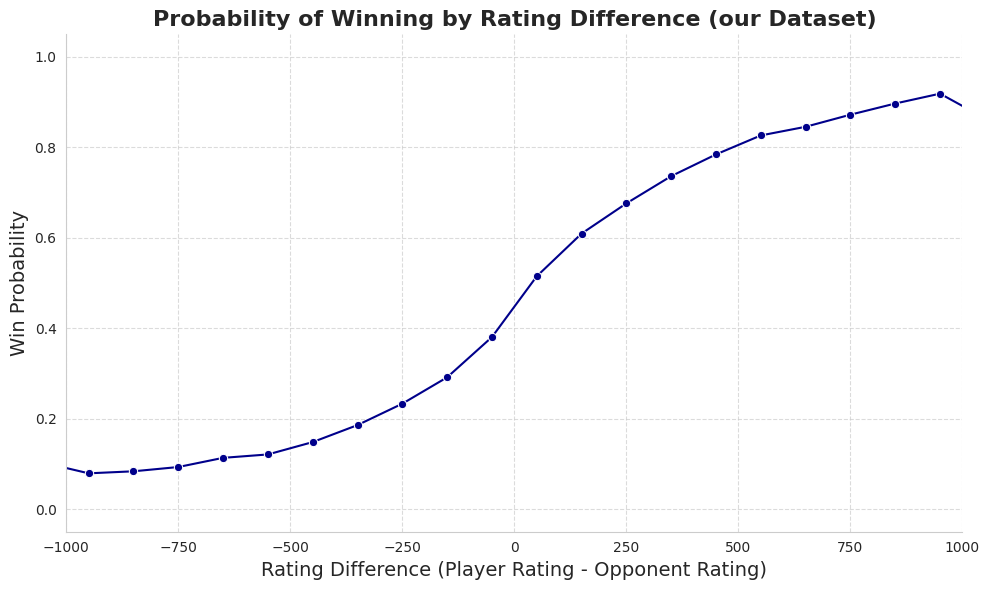

In [ ]:

# Create a rating difference column
players_regression_data['rating_diff'] = players_regression_data['player_rating'] - players_regression_data['opponent_rating']

# Create rating difference

players_regression_data['win_flag'] = (players_regression_data['player_result'] == 1.0).astype(int)

# Bin the rating differences into intervals
bins = np.arange(-3000, 3001, 100)  # for example, intervals of 100 rating points
players_regression_data['rating_diff_bin'] = pd.cut(players_regression_data['rating_diff'], bins=bins)

# Calculate mean win probability per bin
grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()

# Extract bin centers for plotting
grouped['bin_center'] = grouped['rating_diff_bin'].apply(lambda x: (x.left + x.right)/2)

sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.lineplot(data=grouped, x='bin_center', y='win_flag', marker='o', color='darkblue')
plt.xlim(-1000, 1000)

plt.title('Probability of Winning by Rating Difference (our Dataset)', fontsize=16, fontweight='bold')
plt.xlabel('Rating Difference (Player Rating - Opponent Rating)', fontsize=14)
plt.ylabel('Win Probability', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.savefig('probability_winning', dpi=1000)
plt.show()


KeyboardInterrupt: 

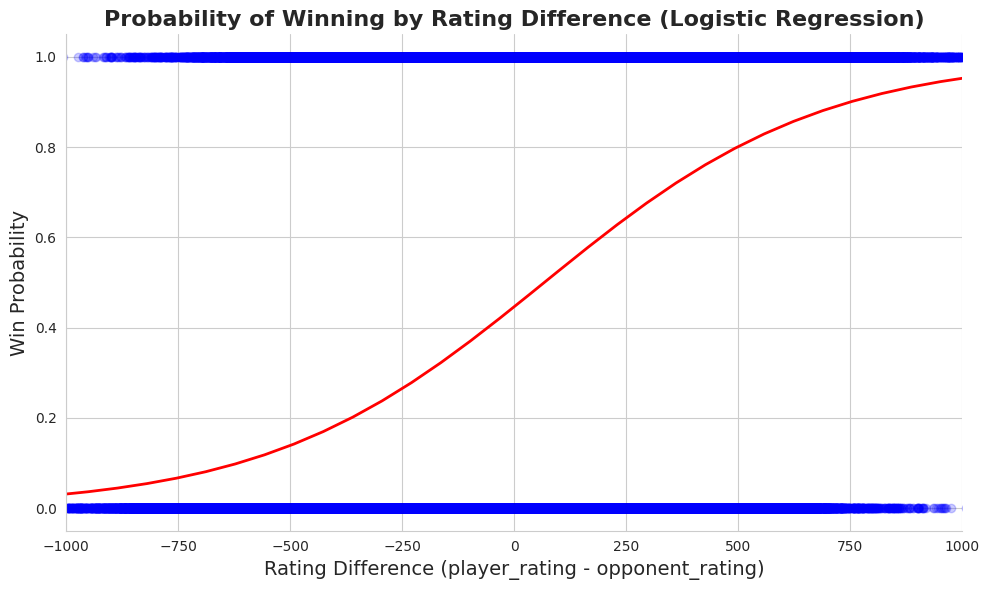

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df already exists and has 'rating_diff' and 'win_flag' columns
# If not, make sure to create them as previously described:
# df['rating_diff'] = df['player_rating'] - df['opponent_rating']
# df['win_flag'] = (df['player_result'] == 1.0).astype(int)

sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

# Plot a logistic regression curve
sns.regplot(
    x='rating_diff',
    y='win_flag',
    data=players_regression_data,
    logistic=True,
    ci=None,
    scatter_kws={'alpha':0.2, 'color':'blue'},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Probability of Winning by Rating Difference (Logistic Regression)', fontsize=16, fontweight='bold')
plt.xlabel('Rating Difference (player_rating - opponent_rating)', fontsize=14)
plt.ylabel('Win Probability', fontsize=14)



# Limit the x-axis range
plt.xlim(-1000, 1000)

sns.despine()
plt.tight_layout()
plt.savefig('probability_winning_regression', dpi=1000)
plt.show()

<ipython-input-105-c4590bd68d8e>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()


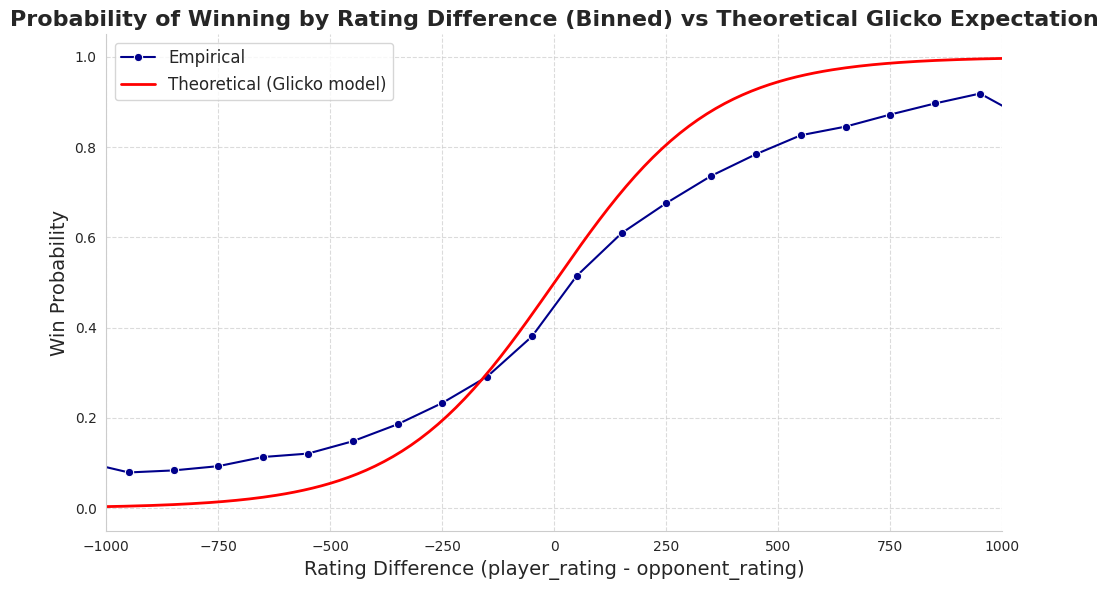

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# Предполагается, что df уже существует и содержит player_rating, opponent_rating, player_result
# Создаём rating_diff и win_flag
players_regression_data['rating_diff'] = players_regression_data['player_rating'] - players_regression_data['opponent_rating']
players_regression_data['win_flag'] = (players_regression_data['player_result'] == 1.0).astype(int)

# Бинирование rating_diff по интервалам
bins = np.arange(-3000, 3001, 100)  # шаг 100 пунктов рейтинга
players_regression_data['rating_diff_bin'] = pd.cut(players_regression_data['rating_diff'], bins=bins)

# Расчёт средней эмпирической вероятности победы по бинам
grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()

# Центр каждого бина
grouped['bin_center'] = grouped['rating_diff_bin'].apply(lambda x: (x.left + x.right)/2)

# Настройка стиля
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

# Линия эмпирической вероятности победы
sns.lineplot(data=grouped, x='bin_center', y='win_flag', marker='o', color='darkblue', label='Empirical')

# Параметры для Glicko
q = math.log(10)/400
RD = 50.0  # предположим средний RD, значение взято для примера
g_RD = 1 / math.sqrt(1 + (3 * (q**2) * (RD**2)) / (math.pi**2))

rating_range = np.arange(-3000, 3001, 10)
# Ожидаемый результат в модели Glicko:
theoretical = 1 / (1 + 10**(-g_RD * (rating_range / 400)))

# Добавляем теоретическую кривую Glicko
plt.plot(rating_range, theoretical, color='red', linewidth=2, label='Theoretical (Glicko model)')

plt.title('Probability of Winning by Rating Difference (Binned) vs Theoretical Glicko Expectation', fontsize=16, fontweight='bold')
plt.xlabel('Rating Difference (player_rating - opponent_rating)', fontsize=14)
plt.ylabel('Win Probability', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-1000, 1000)
sns.despine()
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

<ipython-input-106-57f2bfd0cba3>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()


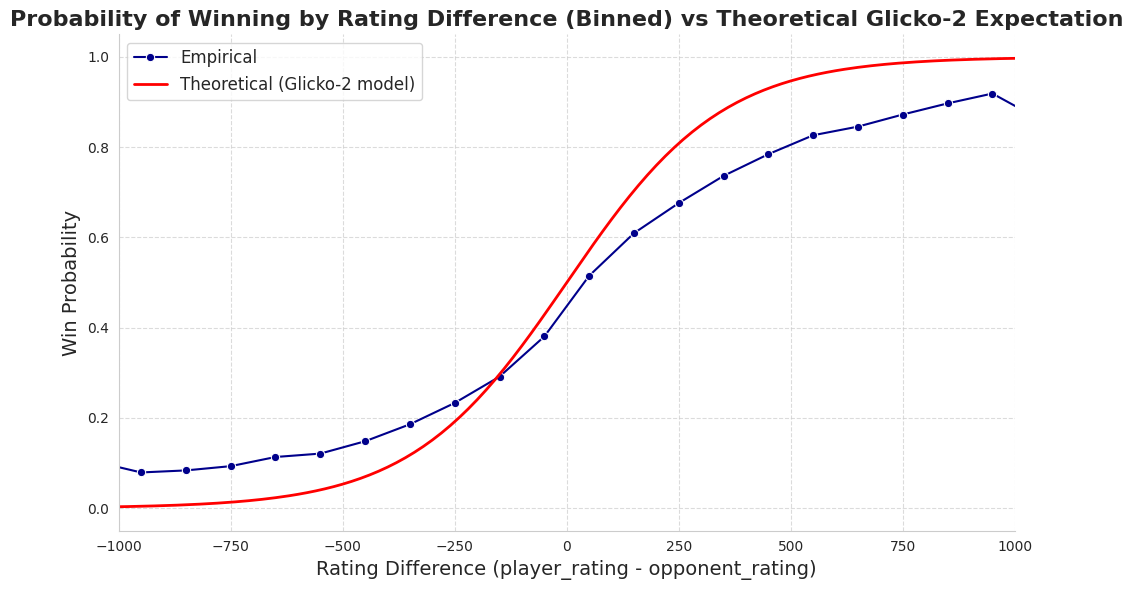

In [ ]:

grouped = players_regression_data.groupby('rating_diff_bin', as_index=False)['win_flag'].mean()
grouped['bin_center'] = grouped['rating_diff_bin'].apply(lambda x: (x.left + x.right)/2)

# Настройка стиля графика
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

# Линия эмпирической вероятности
sns.lineplot(data=grouped, x='bin_center', y='win_flag', marker='o', color='darkblue', label='Empirical')

# Параметры для Glicko-2
q = math.log(10)/400
RD = 50.0  # Предполагаем некоторый средний RD для примера
phi = RD / 173.7178
g_phi = 1 / math.sqrt(1 + (3*(q**2)*(phi**2)/(math.pi**2)))

rating_range = np.arange(-3000, 3001, 10)
# Преобразование в шкалу μ для Glicko-2: μ_diff = rating_diff/173.7178
mu_diff = rating_range / 173.7178

# Расчёт теоретической вероятности победы по Glicko-2
# E_A = 1/(1+exp(-g(phi)*mu_diff))
theoretical = 1/(1+np.exp(-g_phi * mu_diff))

# Добавляем теоретическую кривую Glicko-2
plt.plot(rating_range, theoretical, color='red', linewidth=2, label='Theoretical (Glicko-2 model)')

plt.title('Probability of Winning by Rating Difference (Binned) vs Theoretical Glicko-2 Expectation', fontsize=16, fontweight='bold')
plt.xlabel('Rating Difference (player_rating - opponent_rating)', fontsize=14)
plt.ylabel('Win Probability', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-1000, 1000)

sns.despine()
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('probability_winning_and_theoretical', dpi=1000)
plt.show()

In [ ]:
players_regression_data.drop(columns=['rating_diff_bin', 'win_flag'], inplace=True)

In [ ]:
players_regression_data

,player_name,player_rating,player_title,player_accuracy,is_female,round,date,opponent_rating,player_result,could_win,could_win_05,leader,could_win_prizes,is_white,rating_diff
0,Oleksandr_Bortnyk,3130,GM,82.86,0,1,"Feb 14, 2023, 2:00 PM",3229,0.0,0.0,0.0,0.0,0.0,1,-99
1,FairChess_on_YouTube,3136,GM,91.75,0,1,"Feb 14, 2023, 2:00 PM",3107,1.0,1.0,1.0,0.0,1.0,1,29
2,BogdanDeac,3066,GM,72.16,0,1,"Feb 14, 2023, 2:00 PM",3040,1.0,1.0,1.0,0.0,1.0,1,26
3,Njal28,2958,GM,90.36,0,1,"Feb 14, 2023, 2:00 PM",2760,1.0,1.0,1.0,0.0,1.0,1,198
4,Baku_Boulevard,3103,GM,80.20,0,1,"Feb 14, 2023, 2:00 PM",2888,0.0,0.0,0.0,0.0,0.0,1,215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971307,Fraler15,2384,FM,79.20,0,11,"Nov 1, 2022, 2:00 PM",2190,1.0,0.0,0.0,0.0,0.0,0,194
971308,giomar27,2386,CM,90.58,0,11,"Nov 1, 2022, 2:00 PM",2239,1.0,0.0,0.0,0.0,0.0,0,147
971309,frequentblunders,2226,NM,79.30,0,11,"Nov 1, 2022, 2:00 PM",2262,0.0,0.0,0.0,0.0,0.0,0,-36
971310,TheMagician,2228,FM,86.70,0,11,"Nov 1, 2022, 2:00 PM",1979,1.0,0.0,0.0,0.0,0.0,0,249


In [ ]:
players_regression_data

,player_name,player_rating,player_title,player_accuracy,is_female,round,date,opponent_rating,player_result,could_win,could_win_05,leader,could_win_prizes,is_white,rating_diff
0,Oleksandr_Bortnyk,3130,GM,82.86,0,1,2023-02-14 14:00:00,3229,0.0,0.0,0.0,0.0,0.0,1,-99
1,FairChess_on_YouTube,3136,GM,91.75,0,1,2023-02-14 14:00:00,3107,1.0,1.0,1.0,0.0,1.0,1,29
2,BogdanDeac,3066,GM,72.16,0,1,2023-02-14 14:00:00,3040,1.0,1.0,1.0,0.0,1.0,1,26
3,Njal28,2958,GM,90.36,0,1,2023-02-14 14:00:00,2760,1.0,1.0,1.0,0.0,1.0,1,198
4,Baku_Boulevard,3103,GM,80.20,0,1,2023-02-14 14:00:00,2888,0.0,0.0,0.0,0.0,0.0,1,215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971307,Fraler15,2384,FM,79.20,0,11,2022-11-01 14:00:00,2190,1.0,0.0,0.0,0.0,0.0,0,194
971308,giomar27,2386,CM,90.58,0,11,2022-11-01 14:00:00,2239,1.0,0.0,0.0,0.0,0.0,0,147
971309,frequentblunders,2226,NM,79.30,0,11,2022-11-01 14:00:00,2262,0.0,0.0,0.0,0.0,0.0,0,-36
971310,TheMagician,2228,FM,86.70,0,11,2022-11-01 14:00:00,1979,1.0,0.0,0.0,0.0,0.0,0,249


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# Replace with your actual data loading step if needed.
# Assuming df is your DataFrame loaded from a CSV or directly in memory.
# For example:
# df = pd.read_csv('your_data.csv')

# Example parsing of 'date' column if it's in string format like "Feb 14, 2023, 2:00 PM"
players_regression_data['date'] = pd.to_datetime(players_regression_data['date'], format='%b %d, %Y, %I:%M %p')

# Filter to only consider data from 2022 onwards (as in the previous code)
players_regression_data = players_regression_data.query('date.dt.year >= 2022')

# Define a linear performance rating function similar to previous
def performance_rating_linear(opponent_ratings, score):
    opponent_ratings = np.array(opponent_ratings, dtype=float)
    if len(opponent_ratings) > 0:
        p = score / len(opponent_ratings)
        rc = opponent_ratings.mean()
        dp = 800 * p - 400
        rp = rc + dp
        return round(rp)
    return None

def calc_round_performance(g):
    # g is a group of games by a single player in a single round
    # Separate games "in prizes" vs "not in prizes"
    g_in_prizes = g[g['could_win_prizes'] == 1]
    g_not_in_prizes = g[g['could_win_prizes'] == 0]

    rp = performance_rating_linear(g['opponent_rating'].values, g['player_result'].sum())
    rp_in_prizes = performance_rating_linear(g_in_prizes['opponent_rating'].values, g_in_prizes['player_result'].sum())
    rp_not_in_prizes = performance_rating_linear(g_not_in_prizes['opponent_rating'].values, g_not_in_prizes['player_result'].sum())

    return pd.Series({
        'round_rp': rp,
        'round_rp_in_prizes': rp_in_prizes,
        'round_rp_not_in_prizes': rp_not_in_prizes,
        'num_total': len(g),
        'num_in_prizes': len(g_in_prizes),
        'num_not_in_prizes': len(g_not_in_prizes)
    })

# Group data by player and round to calculate performance metrics per round
df_round_rp = players_regression_data.groupby(['player_name', 'round']).apply(calc_round_performance).reset_index()

# Now, we want to compare rounds 7–10 vs round 11 performance.
# First, ensure we only consider players who have data in these rounds.
players_with_r11 = df_round_rp.query('round == 11 and num_in_prizes >= 10')['player_name'].unique()
df_round_rp = df_round_rp[df_round_rp['player_name'].isin(players_with_r11)]

# Calculate mean performance in rounds 7–10 and compare to round 11
df_r7_10 = df_round_rp.query('7 <= round <= 10').groupby('player_name')[['round_rp_in_prizes']].mean().reset_index()
df_r11 = df_round_rp.query('round == 11')[['player_name','round_rp_in_prizes','round_rp','round_rp_not_in_prizes']]

df_compare = pd.merge(df_r7_10, df_r11, on='player_name', suffixes=('_r7_10', '_r11'))

# Calculate the delta in performance rating when in prizes
df_compare['delta_11_vs_7_10_in_prizes'] = df_compare['round_rp_in_prizes_r11'] - df_compare['round_rp_in_prizes_r7_10']

# Sort by the delta to see who improved or declined the most
df_compare = df_compare.sort_values('delta_11_vs_7_10_in_prizes', ascending=False)

# Display the comparison
print(df_compare)

# Optional: You can apply styling, create plots, etc.
# For example, a bar chart of delta changes:
# df_compare.plot(x='player_name', y='delta_11_vs_7_10_in_prizes', kind='bar', figsize=(12, 5))
# plt.title('Delta in Performance (In Prizes) from Rounds 7-10 to Round 11')
# plt.xlabel('Player')
# plt.ylabel('Delta in Performance Rating')
# plt.show()


             player_name  round_rp_in_prizes_r7_10  round_rp_in_prizes_r11  \
1       DanielNaroditsky                   3139.50                  3241.0   
11    Polish_fighter3000                   3153.50                  3244.0   
14              jefferyx                   3193.25                  3266.0   
3   FairChess_on_YouTube                   3179.75                  3196.0   
2         FabianoCaruana                   3223.00                  3184.0   
9                 Njal28                   3222.25                  3179.0   
18         wonderfultime                   3135.50                  3073.0   
6                 Hikaru                   3233.75                  3153.0   
17             vi_pranav                   3149.50                  3064.0   
16           rasmussvane                   3091.50                  3003.0   
7                 Jospem                   3197.50                  3096.0   
5           Firouzja2003                   3265.50              

<ipython-input-97-b31bd1d092a6>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_round_rp = players_regression_data.groupby(['player_name', 'round']).apply(calc_round_performance).reset_index()


In [ ]:
players_with_r11

array(['BogdanDeac', 'DanielNaroditsky', 'FabianoCaruana',
       'FairChess_on_YouTube', 'Fandorine', 'Firouzja2003', 'Hikaru',
       'Jospem', 'Msb2', 'Njal28', 'Oleksandr_Bortnyk',
       'Polish_fighter3000', 'TigrVShlyape', 'Zhigalko_Sergei',
       'jefferyx', 'mishanick', 'rasmussvane', 'vi_pranav',
       'wonderfultime'], dtype=object)

In [ ]:
df_compare

,player_name,round_rp_in_prizes_r7_10,round_rp_in_prizes_r11,round_rp,round_rp_not_in_prizes,delta_11_vs_7_10_in_prizes
1,DanielNaroditsky,3139.50,3241.0,3068.0,3044.0,101.50
11,Polish_fighter3000,3153.50,3244.0,3140.0,3126.0,90.50
14,jefferyx,3193.25,3266.0,3054.0,3018.0,72.75
3,FairChess_on_YouTube,3179.75,3196.0,3090.0,3076.0,16.25
2,FabianoCaruana,3223.00,3184.0,3066.0,3042.0,-39.00
9,Njal28,3222.25,3179.0,3032.0,3004.0,-43.25
18,wonderfultime,3135.50,3073.0,3047.0,3044.0,-62.50
6,Hikaru,3233.75,3153.0,3186.0,3190.0,-80.75
17,vi_pranav,3149.50,3064.0,2995.0,2986.0,-85.50
16,rasmussvane,3091.50,3003.0,2978.0,2974.0,-88.50
